<a href="https://colab.research.google.com/github/ilijaaaa/siap/blob/main/siap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predikcija religija država - SIAP projekat**
Ilija Vitošević E2 86/2025 i
Nikola Magdić E2 52/2025

# **O projektu:**
Razvijamo sistem za predikciju religije država na osnovu csv skupa
podataka uz evaluaciju različitih klasifikacionih algoritama i analizu značajnih pojedinih atributa. Analizom simbola i boja na zastavama, u kombinaciji sa geopolitičkim podacima, može se ustanoviti u
kojoj meri vizuelni identitet države opisuje njen kulturni i religijski profil.

## **Eksplorativna analiza**
Ova analiza podeljena je na tri dela. U prvom delu se bavimo prostom analizom distribucijom određenih atributa koje smo procenili kao najbitnije za naš zadatak. U drugom delu smo konkretno upoređivali atribut religion sa ostalim atributima koje smo smatrali najkorisnijim u istraživanju. U trećem delu prisutna je matrica korelacije koja prikazuje međusobni odnos numeričkih atrbuta.

**Korišćene biblioteke u delu eksplorativne analize:**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

**Učitavanje skupa podataka i prikaz osnovnih detalja o njemu:**

(Za učitavanje je potrebno da fajl imate lokalno kod sebe i da ga dodate u dijalog prozoru nakon pokretanja izvršavanja.)

In [ ]:
uploaded = files.upload()

columns = [
    "name","landmass","zone","area","population","language","religion","bars","stripes","colours",
    "red","green","blue","gold","white","black","orange","mainhue","circles","crosses",
    "saltires","quarters","sunstars","crescent","triangle","icon","animate","text","topleft","botright"
]

df = pd.read_csv("flag.data", header=None, names=columns)

print('Skup podataka:')
print(df)

print('\nDimenzije df-a:')
print(df.shape)

print('\nProvera da li postoje nedostajuće vrednosti:')
print(df.isna().sum())

Saving flag.data to flag (2).data
Skup podataka:
               name  landmass  zone  area  population  language  religion  \
0       Afghanistan         5     1   648          16        10         2   
1           Albania         3     1    29           3         6         6   
2           Algeria         4     1  2388          20         8         2   
3    American-Samoa         6     3     0           0         1         1   
4           Andorra         3     1     0           0         6         0   
..              ...       ...   ...   ...         ...       ...       ...   
189   Western-Samoa         6     3     3           0         1         1   
190      Yugoslavia         3     1   256          22         6         6   
191           Zaire         4     2   905          28        10         5   
192          Zambia         4     2   753           6        10         5   
193        Zimbabwe         4     2   391           8        10         5   

     bars  stripes  colour

Podaci su uspešno učitani. Skup ima 194 reda i 30 kolona. Nema nedostajućih vrednosti.

Na početku ove ćelije koda imamo potrebu da definišemo columns kao niz oznaka kolona, jer u skupu podataka ne postoji heder koji bi te kolone opisao.

Proveravamo još postojanje duplikata.

In [ ]:
print(df.nunique())

name          194
landmass        6
zone            4
area          136
population     48
language       10
religion        8
bars            5
stripes        12
colours         8
red             2
green           2
blue            2
gold            2
white           2
black           2
orange          2
mainhue         8
circles         4
crosses         3
saltires        2
quarters        3
sunstars       14
crescent        2
triangle        2
icon            2
animate         2
text            2
topleft         7
botright        8
dtype: int64


Na prvi pogled izgleda da u skupu podataka nema duplikata, jer jedini atribut koji je jedinstven *name* ima različitu vrednost za sve primerke u skupu. Ipak, ručnim pregledom skupa podataka koji je moguć jer je skup mali, otkriven je jedan duplikat, koji je obrisan iz skupa.

In [ ]:
print(df[df['name'].str.contains('Arg', case=False)])

df = df.drop(8)
print("\nDimenzije skupa nakon izbacivanja duplikata:")
print(df.shape)

          name  landmass  zone  area  population  language  religion  bars  \
8    Argentina         2     3  2777          28         2         0     0   
9    Argentine         2     3  2777          28         2         0     0   
135    Parguay         2     3   407           3         2         0     0   

     stripes  colours  ...  saltires  quarters  sunstars  crescent  triangle  \
8          3        2  ...         0         0         0         0         0   
9          3        3  ...         0         0         1         0         0   
135        3        6  ...         0         0         1         0         0   

     icon  animate text  topleft  botright  
8       0        0    0     blue      blue  
9       0        0    0     blue      blue  
135     1        1    1      red      blue  

[3 rows x 30 columns]

Dimenzije skupa nakon izbacivanja duplikata:
(193, 30)


**Sledi prvi deo analize:**

1. Prati se distribucija mainhue (dominantne boje) po broju zemalja.

/tmp/ipython-input-166/783593061.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mainhue', palette=colors.keys(), edgecolor='black', linewidth=2)


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'green'),
  Text(1, 0, 'red'),
  Text(2, 0, 'blue'),
  Text(3, 0, 'gold'),
  Text(4, 0, 'white'),
  Text(5, 0, 'orange'),
  Text(6, 0, 'black'),
  Text(7, 0, 'brown')])

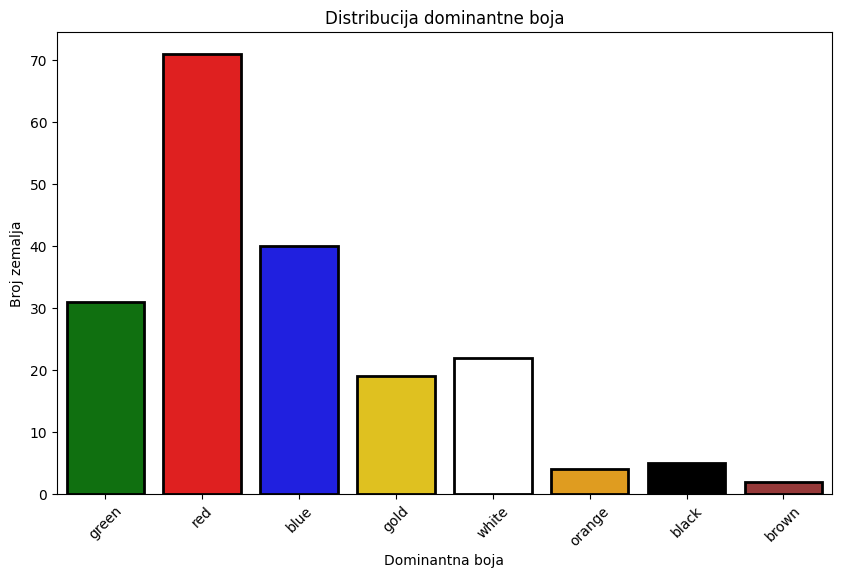

In [ ]:
colors = {'green': 'green', 'red' : 'red', 'blue': 'blue', 'gold': 'gold',
          'white': 'white', 'orange': 'orange', 'black': 'black', 'brown': 'brown'}
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='mainhue', palette=colors.keys(), edgecolor='black', linewidth=2)
plt.title('Distribucija dominantne boja')
plt.xlabel('Dominantna boja')
plt.ylabel('Broj zemalja')
plt.xticks(rotation=45)

Primetno je da crvena boja ima najdominantnije prisustvo na svetskim zastavama, dok je najmanje prisutna braon boja.

2. Prati se distribucija broja boja (colours) na zastavama po broju zemalja.

/tmp/ipython-input-166/1768390674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='colours', edgecolor='black', linewidth=2, palette='Set1')


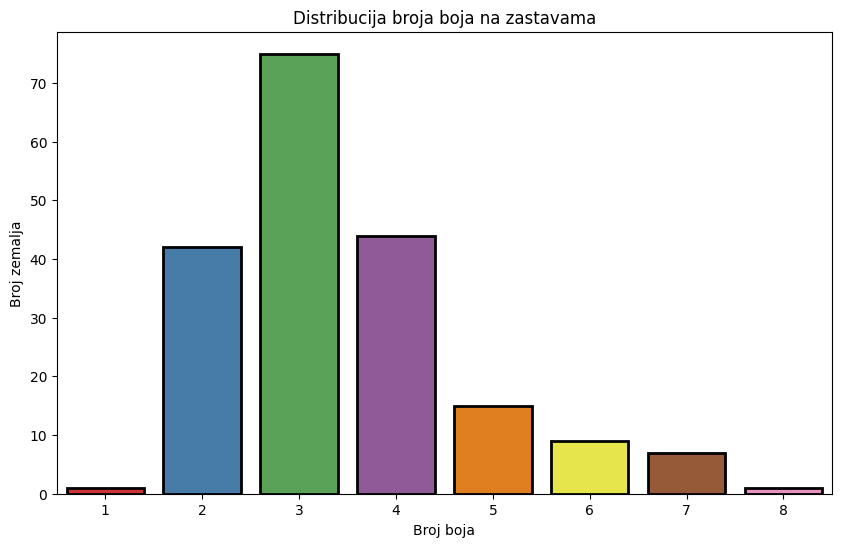

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='colours', edgecolor='black', linewidth=2, palette='Set1')
plt.title('Distribucija broja boja na zastavama')
plt.xlabel('Broj boja')
plt.ylabel('Broj zemalja')
plt.show()

Primetno je da najveći broj zastava ima tri boje na sebi, a najređe su zastave sa jednom i osam boja.

3. Prati se distribucija religija (religion) po broju zemalja, čime se završava prvi deo eksplorativne analize.

/tmp/ipython-input-166/3067525067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='religion', edgecolor='black', linewidth=2, palette='Set1')


([<matplotlib.axis.XTick at 0x7e0bc4960bc0>,
 [Text(0, 0, 'Catholic'),
  Text(1, 0, 'Other Christian'),
  Text(2, 0, 'Muslim'),
  Text(3, 0, 'Buddhist'),
  Text(4, 0, 'Hindu'),
  Text(5, 0, 'Ethnic'),
  Text(6, 0, 'Marxist'),
  Text(7, 0, 'Others')])

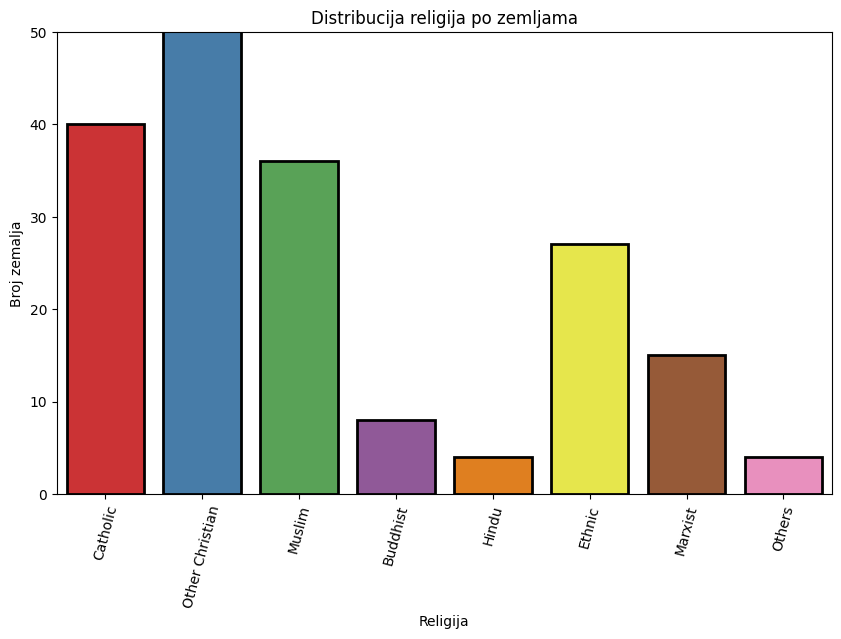

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='religion', edgecolor='black', linewidth=2, palette='Set1')
plt.title('Distribucija religija po zemljama')
plt.xlabel('Religija')
plt.ylabel('Broj zemalja')
plt.ylim(0, 50)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6, 7],
           labels=['Catholic', 'Other Christian', 'Muslim', 'Buddhist', 'Hindu', 'Ethnic', 'Marxist', 'Others'], rotation=75)

U ovoj podeli dominiraju hrišćanske zemlje koje su rezdeljene na ostale hrišćane i katolike zasebno, gde ostalih hrišćana ima najviše u odnosu na sve ostale grupe. Najmanji je broj zemalja gde je dominantna religija hinduizam ili neka druga religija.

*(Skup podataka je iz 1986. godine, te se stoga pojavljuju zemlje definisane kao markističke.)*

**Sada sledi drugi deo eksplorativne analize.**

U pitanju je poređenje atributa između klasa, gde je sa jedne strane uvek atribut religion.

Evo popisa atributa koji se prate, a za koje smo procenilio da su najznačajniji za procenu religije na osnovu elemenata na zastavi:
* bars = vertikalne pruge, koje religije imaju koliko zastava sa n brojem vertikalnih pruga
* stipes = horizontalne pruge
* colors = broj boja na zastavi
* circles = broj krugova na zastavi
* crosses = broj krstova na zastavi
* sunstars = broj sunaca i zvezdi na zastavi

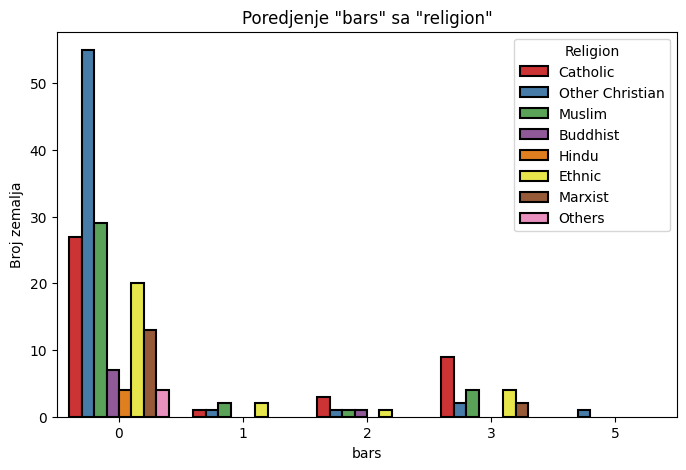

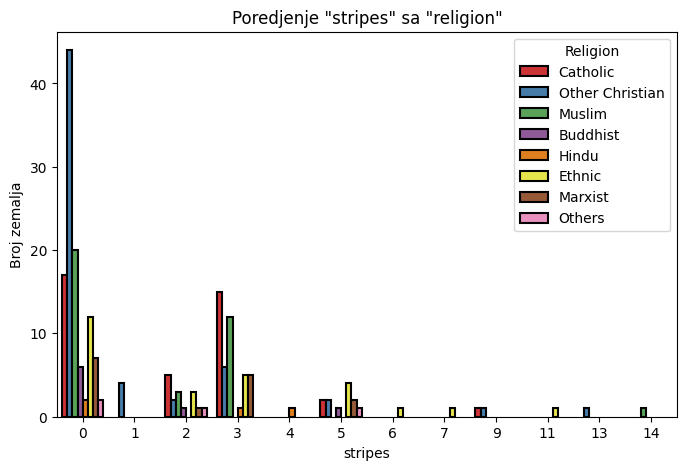

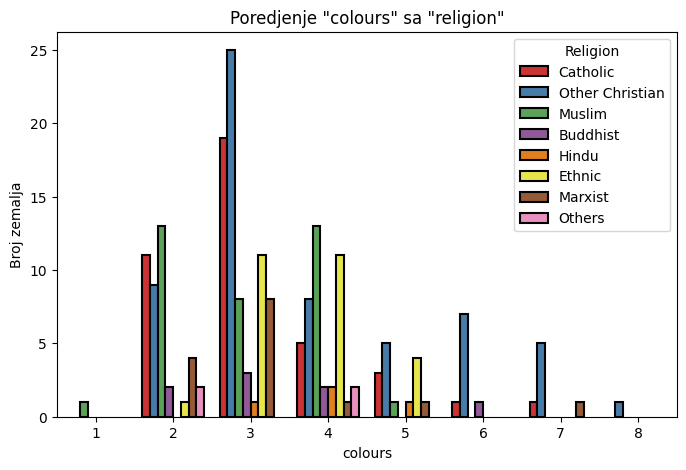

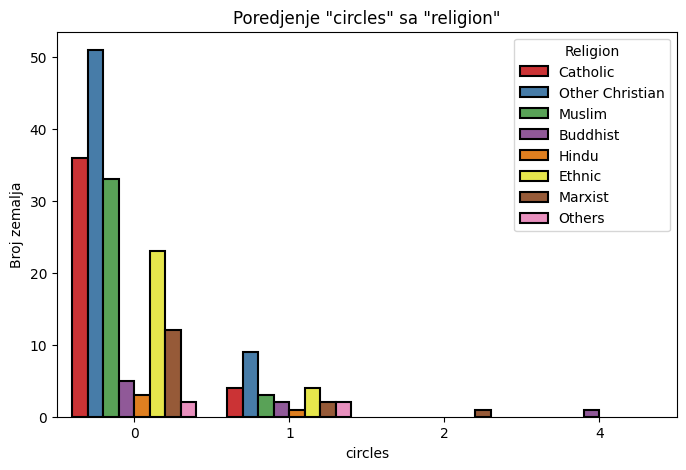

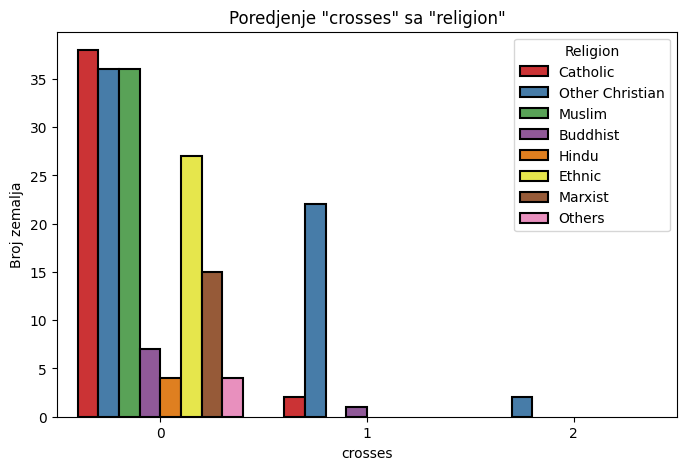

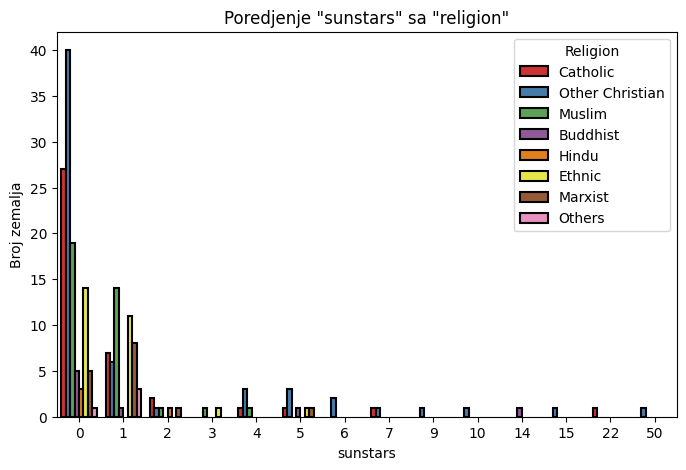

In [ ]:
# Definisanje legendi za religije
religion_labels = {
    0: 'Catholic', 1: 'Other Christian', 2: 'Muslim', 3: 'Buddhist', 4: 'Hindu', 5: 'Ethnic', 6: 'Marxist', 7: 'Others'
}

target_variable = 'religion'
compare_features = ['bars', 'stripes', 'colours', 'circles', 'crosses', 'sunstars']

for feature in compare_features:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x=feature, hue=target_variable, edgecolor='black', linewidth=1.5, palette='Set1')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [religion_labels[int(label)] for label in labels], title='Religion', loc='upper right')

    plt.title(f'Poredjenje "{feature}" sa "{target_variable}"')
    plt.xlabel(feature)
    plt.ylabel('Broj zemalja')
    plt.show()

* **bars** - Na osnovu ovih rezultata, vidi se da najveći broj zastava koje pripadaju državama ostalih hrišćana nemaju nijednu vertikalnu prugu, a to važi i za muslimane i katolike u velikom broju. Primetan je rezultat u delu za tri vertikalne pruge, gde se ističu katoličke države.
* **stripes** - Na osnovu ovih rezultata, vidi se da je najveći broj država koje imaju nula horizontalnih pruga ponovo izražen na isti način kao i u primeru iznad. Dodatno, ako država ima tri horizontalne pruge, uglavnom će to biti katolička ili muslimanska država.
* **colours** - Na osnovu ovih rezultata, vidi se da je među svih hrišćanima najčešći model zastave koja ima tri boje, a kod muslimanskih država tu su ili zastave sa dve ili četiri boje najčešće. Istakle su se još i etničke religije koje uglavnom imaju ili tri ili četiri boje.
* **circles** - Na osnovu ovih rezultata, vidi se da ako zastava ima jedan krug, najveće su šanse da je u pitanju zastava države gde su ostali hrišćani, što je najznačajnija informacija sa ovog grafika
* **crosses** - Na osnovu ovih rezultata, vidi se da ako država ima jedan krst, gotovo sigurno je u pitanju zastava države ostalih hrišćana, a to mogu biti još i katolička ili budistička država. Ako je broj krstva dva, to su uvek ostali hrišćani.
* **sunstars** - Na osnovu ovih rezultata, vidi se da ako država ima na zastavi jednu zvezdu ili sunce, da je to uglavnom muslimanska država, mada u stopu ih prate države koje imaju etničke religije. Ako država nema ništa od ovoga na zastavi to najčešće ukazuje da je u pitanju neka od hrišćanskih zastava.

Sada se posmatraju kontinenti (landmass) i oblasti sveta podeljene u kvadrante na mapi (zone) prema dominantnim bojama, a potom i prema religijama.

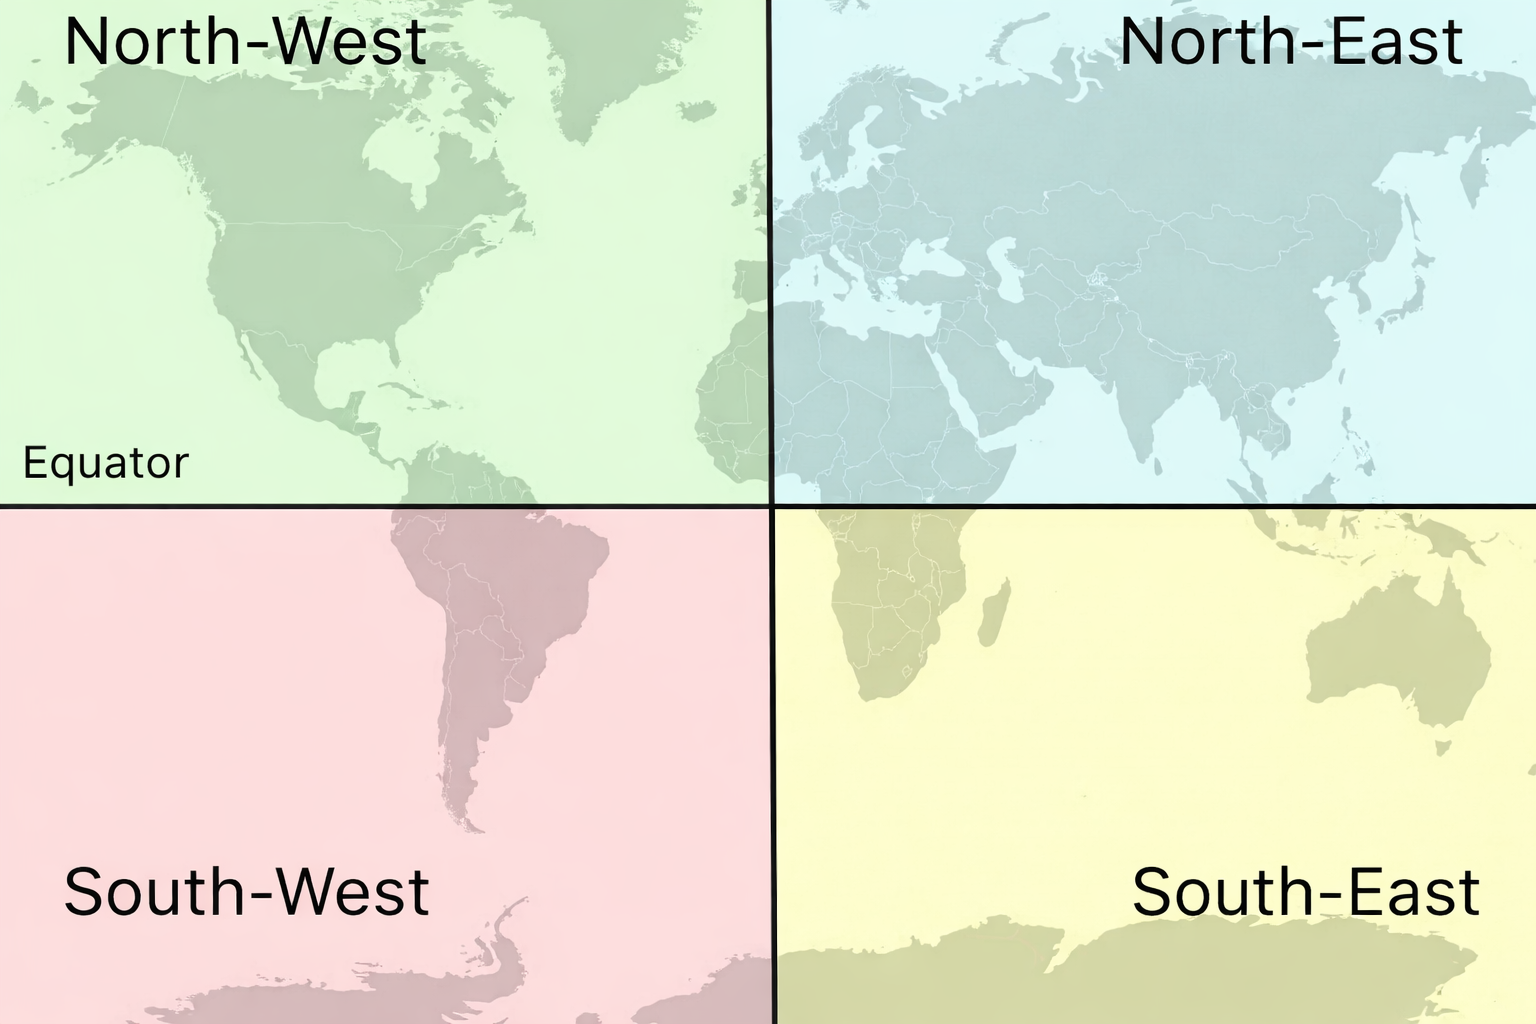

Iznad je priložena slika koja grafički opisuje geografsku podelu na kvadrante, zarad kasnijeg lakšeg tumačenja rezultata analize.

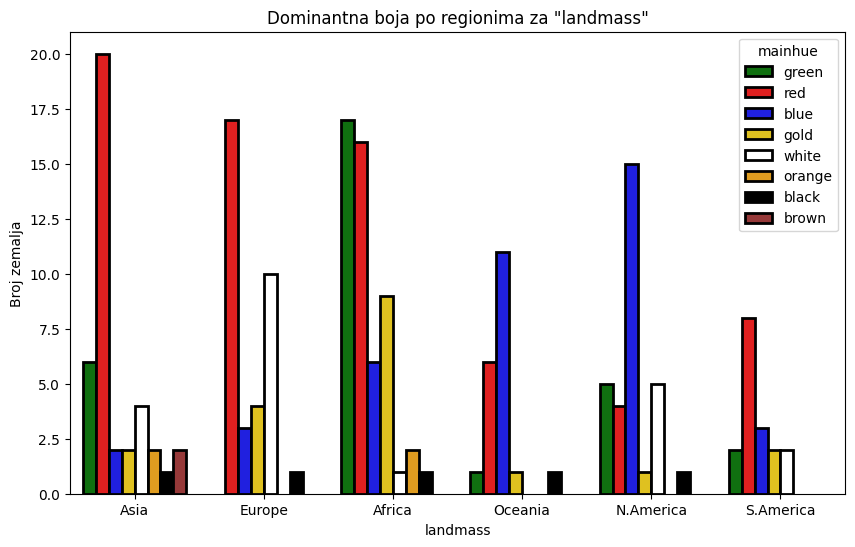

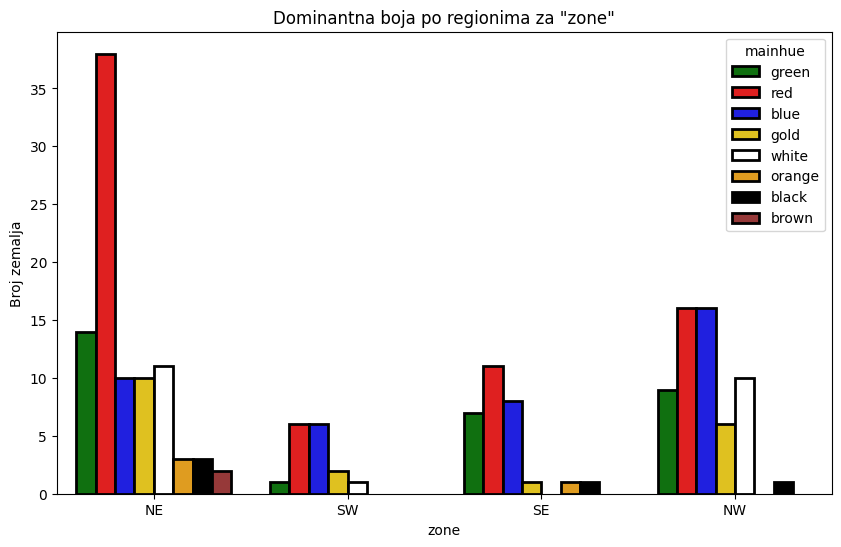

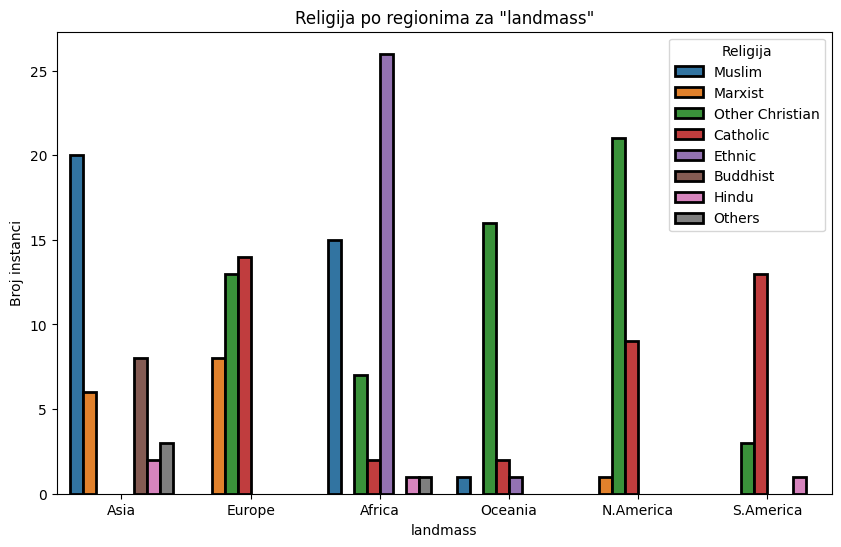

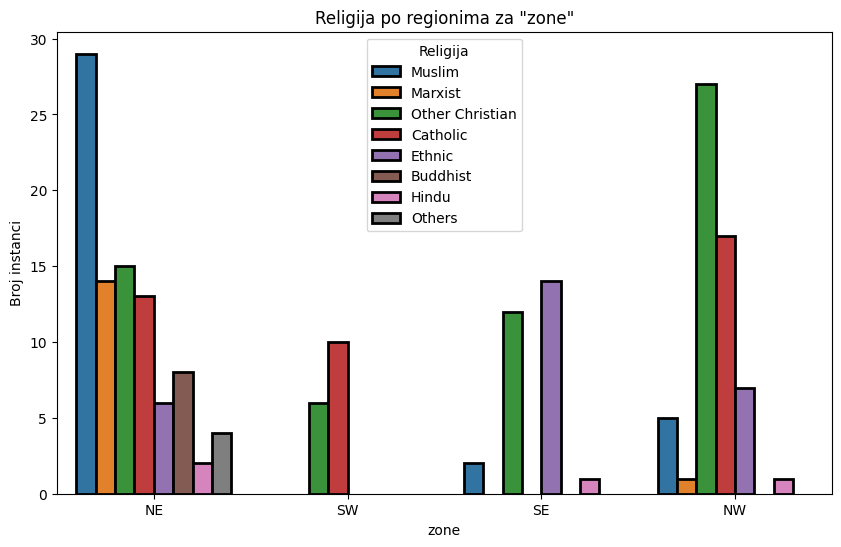

In [ ]:
df = pd.read_csv("flag.data", header=None, names=columns)

# Mapiranje za geografske karakteristike
landmass_map = {1:'N.America',2:'S.America',3:'Europe',4:'Africa',5:'Asia',6:'Oceania'}
zone_map = {1:'NE',2:'SE',3:'SW',4:'NW'}
religion_map = {0:'Catholic',1:'Other Christian',2:'Muslim',3:'Buddhist', 4:'Hindu',5:'Ethnic',6:'Marxist',7:'Others'}

# Zamena vrednosti u DataFrame-u
df['landmass'] = df['landmass'].map(landmass_map)
df['zone'] = df['zone'].map(zone_map)
df['religion'] = df['religion'].map(religion_map)

regional_features = ['landmass', 'zone']

# Deo po dominantnoj boji
for feature in regional_features:
    plt.figure(figsize=(10, 6))
    palette = {hue: hue for hue in df['mainhue'].unique()}

    sns.countplot(
        data=df,
        x=feature,
        hue='mainhue',
        palette=palette,
        edgecolor='black',
        linewidth=2
    )

    plt.title(f'Dominantna boja po regionima za "{feature}"')
    plt.xlabel(feature)
    plt.ylabel('Broj zemalja')
    plt.show()

#Deo po religiji
for feature in regional_features:
    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x=feature,
        hue='religion',
        edgecolor='black',
        linewidth=2
    )

    plt.title(f'Religija po regionima za "{feature}"')
    plt.xlabel(feature)
    plt.ylabel('Broj instanci')
    plt.legend(title='Religija')
    plt.show()

**Dominantna boja:**
* **landmass** - Crvena boja je prikazana kao najdominantnija boja u Aziji, Evropi i Južnoj Americi, a jak rezultat prisutan je i u Africi. Na prva tri pomenuta kontinenta crvena je daleko prisutnija od ostalih boja kao dominantna. U Africi malo veći stepen dominacije ima zelena boja. Plava boja je najjača u Severnoj Americi i Okeaniji. Dodatno, bela boja se dosta ističe u Evropi, a žuta u Africi.
* **zone** - U severo-istočnom kvadrantu potpuno dominira crvena boha, dok su u severozapadnom izjednačene plava i crvena. Ta izjednačenost važi i za jugo-zapadni kvadrant. U jugo-istočnom kvadrantu blagu prednost ima crvena boja, a prate je plava i zelena.

**Religija**
* **landmass** - U Aziji je najveći broj muslimanskih zemalja. U Evropi su prisutne samo tri relgije, najčešća je katoličanstvo, vrlo blisko je prati ostalo hrišćanstvo, a potom su prisutne i zemlje označene kao marksističke. U Africi je najprisutnija etnička religija, a po broju su se istale i muslimanske države. U Okeaniji i Severnoj Americi dominiraju ostalu hrišćani, dok je u slučaju Južne Amerike dominacija pripala katolicima.
* **zone** - U severo-istočnom kvadrantu najzastuljenije su muslimanske zemelje. U severo-zapadnom to su ostali hrišćani, a potom i katolici. U jugo-istočnom najviše su prisutne etničke religije i ostali hrišćani. Na kraju, u jugo-zapadnom kvadrantu, prisutni su samo ostali hrišćani i katolici kojih ima više.

Sledeći grafik će sublimirati ovaj deo u sagledavanju rasporeda dominantnih boja zastava u odnosu na religije.

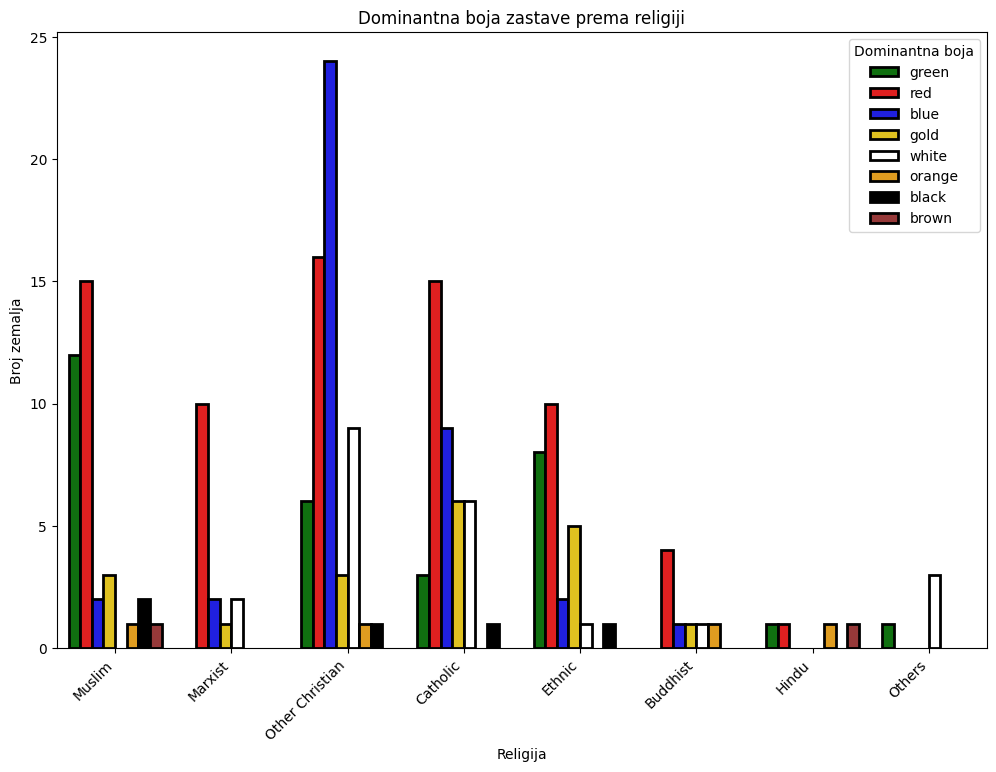

In [ ]:
df = pd.read_csv("flag.data", header=None, names=columns)

df['religion'] = df['religion'].map(religion_labels)

plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='religion', hue='mainhue', palette=colors, edgecolor='black', linewidth=2)
plt.title('Dominantna boja zastave prema religiji')
plt.xlabel('Religija')
plt.ylabel('Broj zemalja')
plt.legend(title='Dominantna boja', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.show()

Primetno je da na zastavama muslimanskih država dominiraju crvena i zelena boju kao glavne boje, isti slučaj je i kod država čije su religije etničke. Kod marksističkih država najdominantnija je crvena boja, kao i kod budističkih. Kod ostalih Hrišćana, a i kod katolika u prve tri boje nalaze se crvena, plava i bela po stepenu dominantnosti. Kod ostalih država najviše se ističe bela boja, dok kod hinduističkih država nema jasne najdominantnije boje.

**Sada sledi treći i poslednji deo eksplorativne analize, korelaciona matrica:**

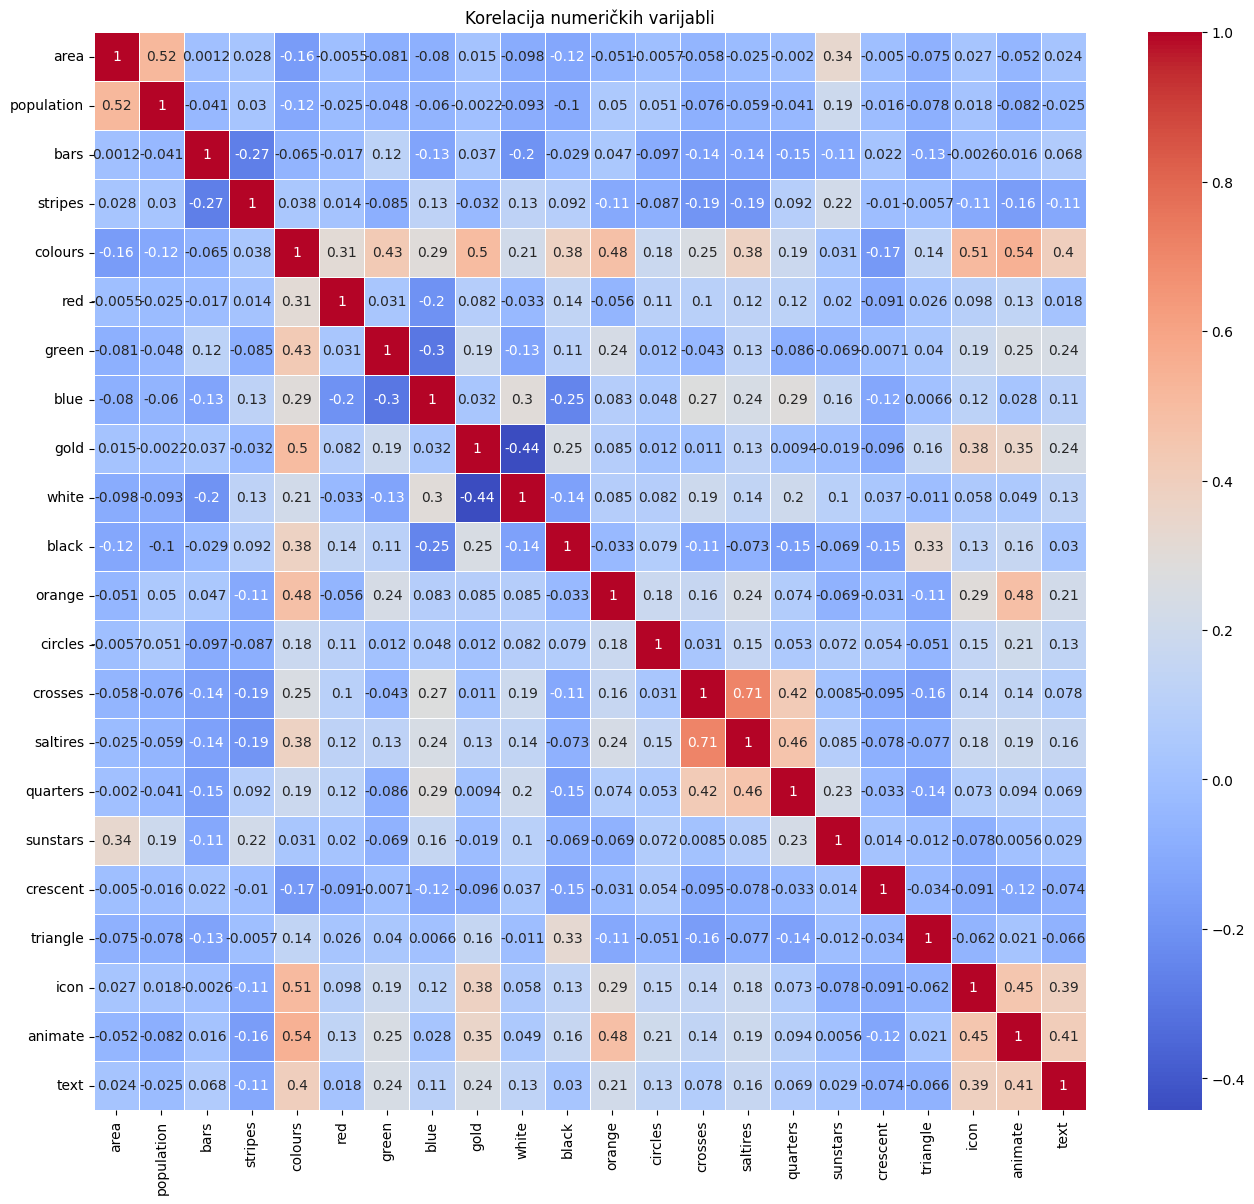

In [ ]:
numerical_features = ['area', 'population', 'bars', 'stripes', 'colours', 'red', 'green', 'blue', 'gold', 'white',
                      'black', 'orange', 'circles', 'crosses', 'saltires', 'quarters', 'sunstars', 'crescent',
                      'triangle', 'icon', 'animate', 'text']

plt.figure(figsize=(16, 14))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korelacija numeričkih varijabli')
plt.show()

Ova matrica daje uvid u odnose izreženih atributa, a ovo su zaključci:
* area i population -> veće zemlje imaju veće populacije
* area i sunstars -> veća površina imaće više zvezdi i sunaca na zastavi
* bars i stripes -> ima jednih, neće biti drugih
* bars i white -> vertikalne pruge i bela boja se ne dešavaju zajedno
* colors i red/green/gold/orange/icon/animate/text -> više boja, pa pojaviće se i crvena/zelena/žuta/narandžasta/sličica/tekst
* green i blue -> isključuju jedna drugu
* blue i white -> oćekuju jedna drugu
* blue i black -> isključuju jedna drugu
* gold i animate/icon -> očekuju jedni druge
* gold i white -> isključuju se
* crosses i saltiers -> očekuju se (objašnjenje atributa saltiers: saltiers je oznaka za postojanje Andrejinog krsta na zastavi, on izgleda kao ćirilično slovo h, glavni primer može biti zastava Škotske)

## **Random Forest - Ilija**

Klasifikator Random Forest se bazira na konceptu ansambla stabala
odluke, gde se kombinuje veliki broj stabala treniranih na
različitim podskupovima podataka. Konačna klasifikacija
se dobija većinskom odlukom svih stabala.

**Biblioteke potrebne u delu koji se koristi za Random Forest**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, log_loss
from sklearn.preprocessing import StandardScaler

import shap

**Učitavanje fajla**

In [ ]:
print("Uploadujte fajl 'flag.data'")
uploaded = files.upload()

columns = [
    "name","landmass","zone","area","population","language","religion","bars","stripes","colours",
    "red","green","blue","gold","white","black","orange","mainhue","circles","crosses",
    "saltires","quarters","sunstars","crescent","triangle","icon","animate","text","topleft","botright"
]

df = pd.read_csv("flag.data", header=None, names=columns)

Uploadujte fajl 'flag.data'


Saving flag.data to flag.data


**Definisanje target kolone i one-hot encoding za kategoričke atribute**


In [ ]:
target_col = "religion"

X = df.drop(columns=[target_col, "name"])
y = df[target_col]

# One-hot za kategoričke kolone
X = pd.get_dummies(X, columns=["landmass", "zone", "language","mainhue", "topleft", "botright"])

# StandardScaller za numerička obeležja
numeric_features = ["area", "population", "bars", "stripes", "colours", "circles", "crosses", "saltires", "quarters", "sunstars"]
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

Zašto **one-hot encoding**? Jer modeli mašinskog učenja ne mogu da rade direktno sa tekstualnim podacima. Stoga, nakon primene ovog postupka na primeru mainhue postojaće kolone mainhue_red, mainhue_blue i tako dalje u kojima će 0 i 1 označavati da li je ta boja prisutna kao dominantna na određenoj zastavi ili ne.

Zašto **Standard Scaller**? Jer Jer numerički atributi mogu imati vrlo različite raspona vrednosti. Ako ostanu u tim različitim skalama, modeli mašinskog učenja mogu da favorizuju atribute sa većim brojevima. Nakon primene StandardScaler-a, numerički atributi biće transformisani tako da imaju srednju vrednost 0 i standardnu devijaciju 1. Time se obezbeđuje da svaki atribut ravnopravno učestvuje u učenju modela, bez obzira na originalnu skalu.

**Podela na trening i test skup podataka**


In [ ]:
TEST_SIZE = 0.15
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

Početak rada sa ovim modelom zahtevao je najpre da se
ceo skup podataka podeljen na trening skup (85%) i test
skup (15%). Podela je stratifikovana da bi se očuvao
odnos pojavljivanja religija u trening i test skupu.

**Random Forest i Grid Search**

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Najbolji hiperparametri:", grid.best_params_)
print("Najbolji prosečni F1 (CV):", grid.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Najbolji hiperparametri: {'max_depth': 10, 'n_estimators': 200}
Najbolji prosečni F1 (CV): 0.5452890647999343


Na trening skupu izvršena je
pretraga najboljih hiperparametara pomoću unakrsne
validacije sa pet particija. U svakoj iteraciji unakrsne
validacije četiri particije su korišćene za treniranje, dok je
peta služila za validaciju, i taj postupak je ponavljan dok
svaka particija nije jednom iskorišćena za validaciju. Na
osnovu postignutih rezultata izabrani su optimalni
hiperparametri, nakon čega je model ponovo treniran na
celom trening skupu.

Korišćeni parametri:
* Broj različitih stabala koja će postojati u
ansamblu za treniranje zarad donošenja odluke. Korišćene
vrednosti su: 50, 100 i 200.
* Maksimalna dubina stabla, kojom se
kontroliše koliko daleko se stablo razvija. Dodeljene
vrednosti su: 5, 10 i None (nema ograničenja).

Ukratko ove vrednosti će
omogućiti da se pronađe balans između stabilnosti modela
(više
stabala) i kompleksnosti pojedinačnog stabla
(kontrola dubine).

**Graf poređenja: prosečna F1 po n_estimators**

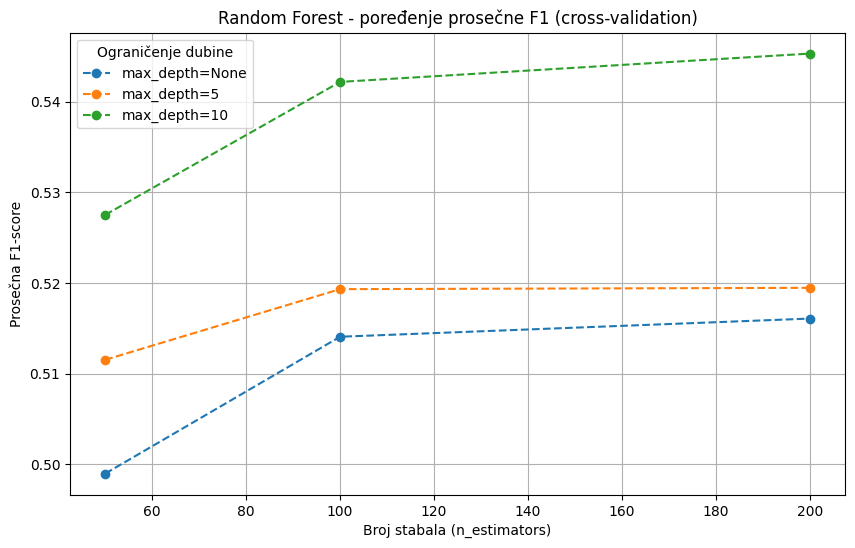

In [ ]:
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(10, 6))
for depth in param_grid['max_depth']:
    if depth is None:
        subset = results[results['param_max_depth'].isna()]
        depth_label = "None"
    else:
        subset = results[results['param_max_depth'] == depth]
        depth_label = str(depth)
    plt.plot(
        subset['param_n_estimators'],
        subset['mean_test_score'],
        marker='o',
        linestyle='dashed',
        label=f'max_depth={depth_label}'
    )
plt.title('Random Forest - poređenje prosečne F1 (cross-validation)')
plt.xlabel('Broj stabala (n_estimators)')
plt.ylabel('Prosečna F1-score')
plt.legend(title="Ograničenje dubine")
plt.grid(True)
plt.show()

Upoređena je f1 mera na trening skupu u
zavisnosti od kriterijuma koji biramo, maksimalne dubine
stabla i broj različitih stabala koja će postojati u ansamblu
za treniranje.

Iz priloženog se vidi da je najbolja kombinacija parametara maksimalna dubina 10 i broj stabala 200, gde f1 mera iznosi približno 0,55.

**Loss funkcija**

Pošto Random Forest ne optimizuje globalnu loss funkciju, definisana je empirijska loss funkcija kao 1 − F1 score kako bi se dobila interpretabilna mera greške za poređenje modela.

In [ ]:
results = pd.DataFrame(grid.cv_results_)

# LOSS = 1 - F1
results['loss'] = 1 - results['mean_test_score']

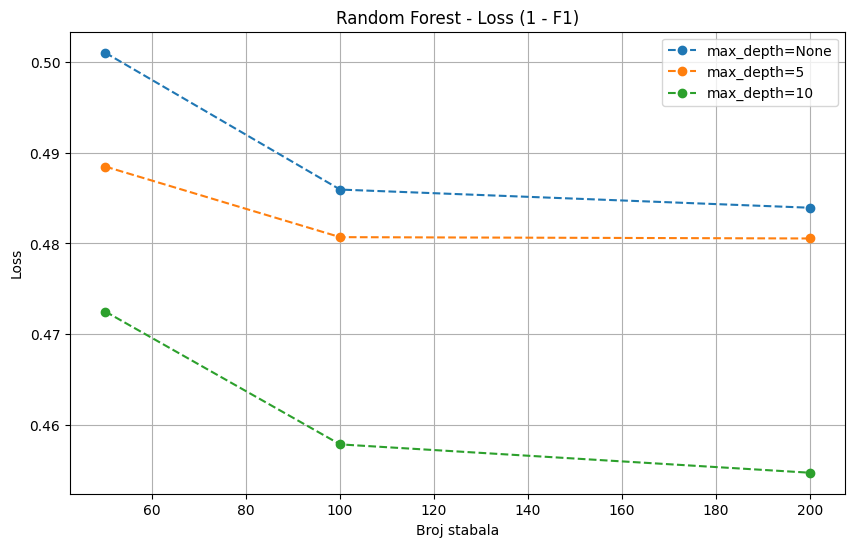

In [ ]:
plt.figure(figsize=(10, 6))

for depth in param_grid['max_depth']:
    if depth is None:
        subset = results[results['param_max_depth'].isna()]
        depth_label = "None"
    else:
        subset = results[results['param_max_depth'] == depth]
        depth_label = str(depth)

    plt.plot(
        subset['param_n_estimators'],
        subset['loss'],
        marker='o',
        linestyle='dashed',
        label=f'max_depth={depth_label}'
    )

plt.title('Random Forest - Loss (1 - F1)')
plt.xlabel('Broj stabala')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Na grafiku se traži minimum loss-a kao oznaka najbolje performanse. Najbolja kombinacija hiperparametara u ovom slučaju je maksimalna dubina 10 i broj stabala 200, što je u skladu sa iznad posmatranim grafikom.

**Evaluacija na test skupu**

In [ ]:
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test) #predikcija verovatnoća modela

f_score = f1_score(y_test, y_pred, average='macro')
test_loss = 1 - f_score
logloss = log_loss(y_test, y_proba)

print("F1 score:", f_score)
print("Test loss (1 - F1):", test_loss)
print("Log loss:", logloss)

F1 score: 0.43409090909090914
Test loss (1 - F1): 0.5659090909090909
Log loss: 2.2091783007895174


Konačna tačnost na podacima izdvojenim na početku
za testiranje je oko 0,43, što daje test loss od oko 0.57.

No, koristi se i **log loss** za dodatnu evaluaciju. Ovim načinom se meri koliko je model siguran u svoje procene. Ima vrednosti u rasponu od 0 ka dalje. Idealno je da bude 0, solidno je 0.5 do 2, a preko 2 se može smatrati loše. Znači manja vrednost log loss-a znači preciznije i pouzdanije verovatnoće. Kako je ovde rezultat 2.21 model se onda smatra nesigurnim u svoje predikcije tj. model često predviđa pogrešne klase sa visokim stepenom sigurnosti.

Slabost rezultata može se opravdati malim skupom podataka i multi-class problemom sa 8 klasa.

**Matrica konfuzije (test skup)**

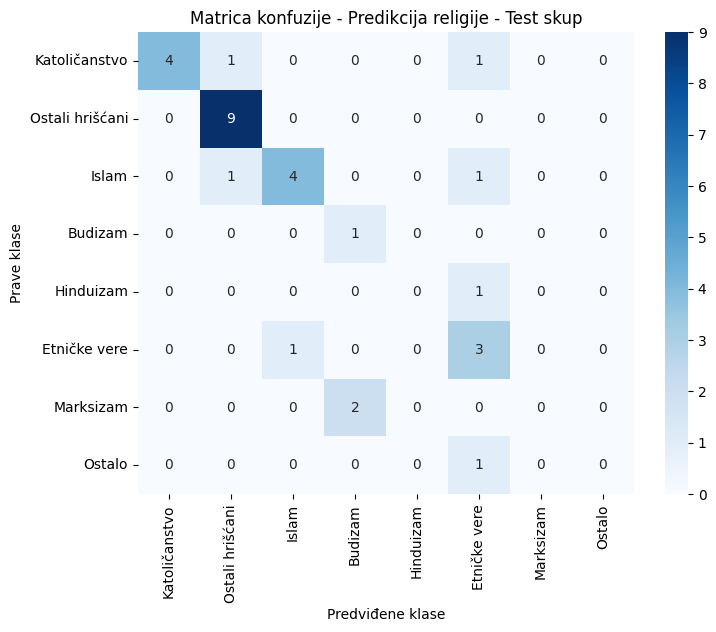

In [ ]:
# Mape za religije
religion_labels = ["Katoličanstvo", "Ostali hrišćani", "Islam", "Budizam", "Hinduizam", "Etničke vere", "Marksizam", "Ostalo"]

# Matrica konfuzije
conf_mat = confusion_matrix(y_test, y_pred)

# Heatmap matrice konfuzije
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=religion_labels,
            yticklabels=religion_labels)
plt.title("Matrica konfuzije - Predikcija religije - Test skup")
plt.xlabel("Predviđene klase")
plt.ylabel("Prave klase")
plt.show()

Na matrici konfuzije koja prikazuje performans nad test skupom vidljivo je sledeće:
* katoličanstvo - uglavom pogađano bez problema
* ostali hrišćani - uvek pogođeno (pre standardizacije bilo uglavnom pogađano)
* islam - uglavom pogađano bez problema
* budizam - pogođen
* hinduizam - promašen, zamenjen entičkim verama
* etničke vere - uglavom pogađano bez problema
* marksizam - promašeno
* ostale vere - promašeno, zamenjeno etničkim verama

**SHAP analiza**

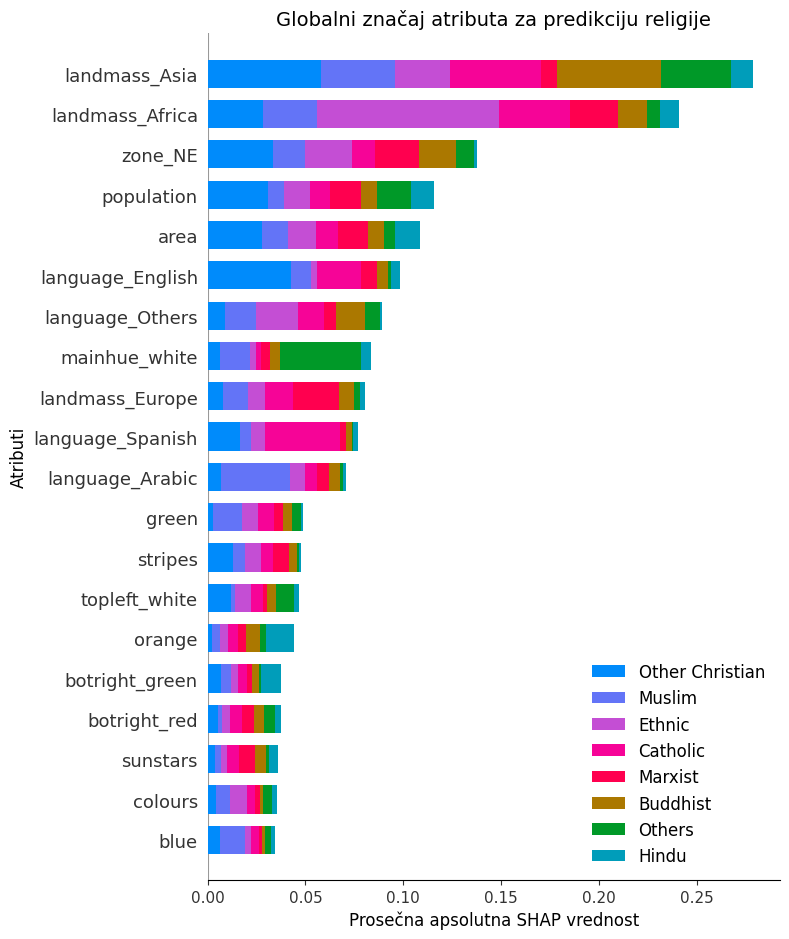

In [ ]:
# Mape kategorija
landmass_map = {
    "1": "N.America", "2": "S.America", "3": "Europe",
    "4": "Africa", "5": "Asia", "6": "Oceania"
}

zone_map = {
    "1": "NE", "2": "SE", "3": "SW", "4": "NW"
}

language_map = {
    "1": "English", "2": "Spanish", "3": "French", "4": "German", "5": "Slavic",
    "6": "Other Indo-European", "7": "Chinese", "8": "Arabic",
    "9": "Japanese/Turkish/Finnish/Magyar", "10": "Others"
}

# Funkcija za preimenovanje dummy kolona
def rename_feature(col):
    if col.startswith("landmass_"):
        key = col.split("_")[1]
        return f"landmass_{landmass_map.get(key, key)}"
    elif col.startswith("zone_"):
        key = col.split("_")[1]
        return f"zone_{zone_map.get(key, key)}"
    elif col.startswith("language_"):
        key = col.split("_")[1]
        return f"language_{language_map.get(key, key)}"
    else:
        return col

# Nova lista imena
new_feature_names = [rename_feature(col) for col in X_test.columns]

# Labele za religije
religion_labels = {0: 'Catholic', 1: 'Other Christian', 2: 'Muslim', 3: 'Buddhist', 4: 'Hindu', 5: 'Ethnic', 6: 'Marxist', 7: 'Others'}
class_names = list(religion_labels.values())

# Explainer za RF
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=new_feature_names,
    class_names=class_names,
    show=False
)

plt.title("Globalni značaj atributa za predikciju religije", fontsize=14)
plt.xlabel("Prosečna apsolutna SHAP vrednost", fontsize=12)
plt.ylabel("Atributi", fontsize=12)
plt.tight_layout()
plt.show()

SHAP je metoda za objašnjavanje predikcija modela. Na grafiku se vidi koliko je feature u proseku jak u donošenju odluka (bez obzira na smer, bio on negativan ili pozitivan).

Grafik prikazuje da su za određivanje religije najbitniji atributi poput kontinenta, geografskog kvadranta, jezika, površine, populacije i dominacije bele boje na zastavi. Različitim bojama prikazano je koliko je u okviru određene religije u nekom atributu bilo značaja za predviđanje iste. Tako na primer, ako je dominantna boja bela, to je najviše pomagalo da se prepoznaju ostale religije.

## **Support Vector Machine - Nikola**

Na osnovu drugog rada iz predloga projekta, koristićemo SVM - Support Vectore Machines model za predikciju religije koristeći opisani skup podataka. SVM je model nadgledanog mašinskog učenja pogodan za rešavanje klasifikacionih problema. Ukratko, ideja SVM je da pronalazi maksimalnu marginu između podataka koju su linearno separabilni. Iako je SVM linearni klasifikator moguće ga je koristiti i za podatke koji nisu linearno separabilni tako što se ulazni podaci mapiraju na višedimenzioni prostor gde ih je moguće linearno razdvajati.

**Importovanje potrebnih biblioteka za predikciju pomoću SVM**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import shap

from google.colab import files
from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score, recall_score, f1_score, log_loss
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

**Učitavanje skupa podataka**

In [ ]:
print("Učitajte fajl 'flag.data'")
uploaded = files.upload()

columns = ["name", "landmass", "zone", "area", "population", "language", "religion", "bars",
           "stripes", "colours", "red", "green", "blue", "gold", "white", "black", "orange",
           "mainhue", "circles", "crosses", "saltires", "quarters", "sunstars", "crescent",
           "triangle", "icon", "animate", "text", "topleft", "botright"]

df = pd.read_csv("flag.data",
                 header=None,
                 names=columns)
df = df.drop(8)

Učitajte fajl 'flag.data'


Saving flag.data to flag (2).data


**Pretprocesiranje skupa podataka**

Budući da su atributi *mainhue*, *topleft* i *botright* kategorički, kao i za Random Forest, koristimo one-hot encoding da bismo ih pretvorili u numeričke vrednosti. Atributi kao što su *language*, *landmass* i *zone* su takođe upotrebom one-hot encoding-a pretvoreni u zasebne kolone za svaku njihovu pojedinačnu vrednost, pošto su u originalnom skupu numerisani brojevima 1,2,3... što bi klasifikatoru moglo da da pogrešnu predstavu da su vrednosti sa većim brojevima značajniji od onih sa manjim.

Atributi koji imaju kontinualne vrednosti kao što je pre svih *area*, koji može da ima za red ili dva veličine veće vrednosti od ostalih atributa, a i za koji je analizom značajnih feature-a utvrđeno da najviše utiče na predikciju (kada njegova vrednost nije standardizovana), ili *population* su normalizovani kako bi se sveli na prosek 0 sa standardnom devijacijom 1.

In [ ]:
target_col = "religion"

X = df.drop(columns=[target_col, "name"])
y = df[target_col]

X = pd.get_dummies(X, columns=["mainhue", "topleft", "botright", "landmass", "zone", "language"])

def_landmass_names = ["landmass_1", "landmass_2", "landmass_3", "landmass_4", "landmass_5", "landmass_6"]
def_zone_names = ["zone_1", "zone_2", "zone_3", "zone_4"]
def_language_names = ["language_1", "language_2", "language_3", "language_4", "language_5", "language_6", "language_7", "language_8", "language_9", "language_10"]

landmasses = ["N. America", "S. America", "Europe", "Africa", "Asia", "Oceania"]
zones = ["NE", "SE", "SW", "NW"]
languages = ["English lang", "Spanish lang", "French lang", "German lang", "Slavic lang", "Other Indo-European lang", "Chinese lang", "Arabic lang", "Jap/Tur/Fin/Mag lang", "Other lang"]

X = X.rename(columns=dict(zip(def_landmass_names, landmasses)))
X = X.rename(columns=dict(zip(def_zone_names, zones)))
X = X.rename(columns=dict(zip(def_language_names, languages)))

scaler = StandardScaler()
columns_for_scale = ["area", "population", "bars", "stripes", "colours", "circles", "crosses", "saltires", "quarters", "sunstars"]
X = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)


**Podela na trening i test skup**

Delimo skup podataka u trening i test skup u odnosu 85-15. Zbog nebalansiranosti klasa pravimo stratifikovanu podelu.

In [ ]:
RANDOM_STATE = 42

x_train, x_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.15,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

**Definisanje parametara modela**

Koristi se SVC sa linear kernelom. Zbog nebalansiranosti klasa koristi se One-to-one pristup koji pravi binarni klasifikator za sve moguće parove klasa, i dodaje atribut class_weight u kome se podešava vrednost na "balanced" kako bi retke klase dobile veću težinu.

Radi se 5-fold unakrsna validacija prilikom obučavanja, zbog male veličine skupa podataka.
Hiperparametar koji se podešava je parametar regularizacije C, da bismo našli najbolju marginu greške - uzimaju se vrednosti na logaritamskoj skali.

In [ ]:
clf_svm = make_pipeline(
    SVC(
          kernel="linear",
          random_state=RANDOM_STATE,
          decision_function_shape="ovo",
          class_weight="balanced")
)

grid = GridSearchCV(
    clf_svm,
    param_grid= {
        "svc__C": [0.01, 0.1, 1, 10, 100],
        },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

**Obučavanje modela**

In [ ]:
grid.fit(x_train, y_train)

print("Najbolji hiperparametri:" + str(grid.best_params_))
print("Najbolji F1:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Najbolji hiperparametri:{'svc__C': 0.1}
Najbolji F1: 0.49569783391211975


**Analiza najbolje vrednosti parametra C**

Analiziranjem dobijenog prosečnog f1 score-a (dobijenog uprosečavanjem rezultata unakrsne validacije) vidi se da je vrednost 0.1 za C dala najbolje rezultate, a i vrednost od 0.01 joj je blizu. Veće vrednosti parametra regularizacije daju začajno lošije rezultate. Najbolji rezultati predikcije za veoma male vrednosti parametra C su očekivane zbog malog skupa podataka i relativno velikog broja atributa naspram njega. Mnogi atributi imaju mali značaj za predikciju pa mala margina greške izaziva njihovo zanemarivanje. Takođe, iako je u skupu podataka dodeljena samo jedna religija svakoj državi, u mnogim državama ne postoji jasna dominantna religija, pa je i logično da podaci ne mogu biti idealno linearno separabilni po tom parametru.

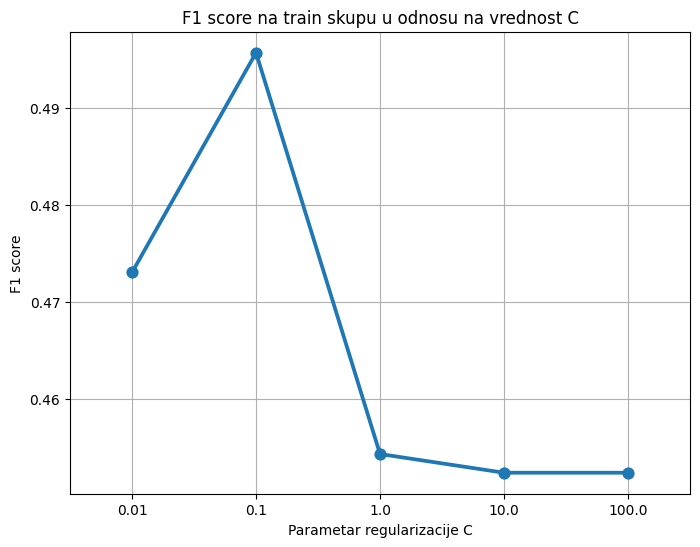

In [ ]:
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8, 6))
sns.pointplot(x = results['param_svc__C'], y = results['mean_test_score'])
plt.title('F1 score na train skupu u odnosu na vrednost C')
plt.xlabel('Parametar regularizacije C')
plt.ylabel('F1 score')
plt.grid(True)
plt.show()

**Evaluacija obučenog modela na test skupu**

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

f1 = f1_score(y_test, y_pred, average="macro")
print("F1 score: ", f1)

F1 score:  0.43302359405300583


Vidimo da je rezultat predikcije dosta slab na test skupu. Zaključak je da Support Vectore Machine nije najbolji model za predikciju religije za korišćeni skup podataka iako bi na osnovu njegovih osobina trebalo da odgovara problemu koji razmatramo. Dalja optimizacija parametara i izbor značajnih atributa bi mogli da budu dalji pravci istraživanja u cilju poboljšanja rezultata.

**Loss funkcija**

Pošto linearni SVM ne optimizuje F1 direktno, definisana je empirijska loss funkcija kao 1 − F1 score kako bi se dobila interpretabilna mera greške za poređenje modela.

In [ ]:
# Empirijski loss
loss = 1 - f1
print("Test loss (1 - F1): ", loss)

# SVM linearni kernel mora imati probability=True da bi se koristio log_loss
best_model_prob = make_pipeline(
    SVC(
        kernel="linear",
        C=grid.best_params_['svc__C'],
        probability=True,  # enable probability estimates
        random_state=RANDOM_STATE,
        decision_function_shape="ovo",
        class_weight="balanced"
    )
)

# retreniranje sa probability=True
best_model_prob.fit(x_train, y_train)
y_proba = best_model_prob.predict_proba(x_test)

ll = log_loss(y_test, y_proba)
print("Log loss: ", ll)

Test loss (1 - F1):  0.5669764059469942
Log loss:  1.2664461184740212


Za dodatnu evaluaciju koristi se i **log loss**, koji meri koliko je model siguran u svoje predikcije. Linearni kernel SVM-a ne daje probabilističke izlaze direktno, pa je potrebno retrenirati model sa probability=True.

Na osnovu verovatnoća predikcije (y_proba = best_model_prob.predict_proba(x_test)), log loss iznosi ≈ 1.27, što ukazuje da model ima umerenu sigurnost u predikcije.
Niža vrednost log loss-a bi značila preciznije i pouzdanije verovatnoće, idealno je 0.

**Matrica konfuzije**

Radi boljeg pregleda rezultata klasifikacije prikazana je matrica konfuzije.

Matrica pokazuje da su najbolje pogađani ostali hrišćani. Budizam i etničke religije vuku najviše lažno pozitivnih rezultata, a islam i katoličanstvo najviše lažno negativnih. Uglavnom su religije sa većim brojem primeraka u skupu bolje pogađane. Religije sa malim brojem primeraka u test skupu su klasifikovane uglavnom kao etničke religije ili budizam. Primetno je da model prepoznaje marksizam kao budizam.

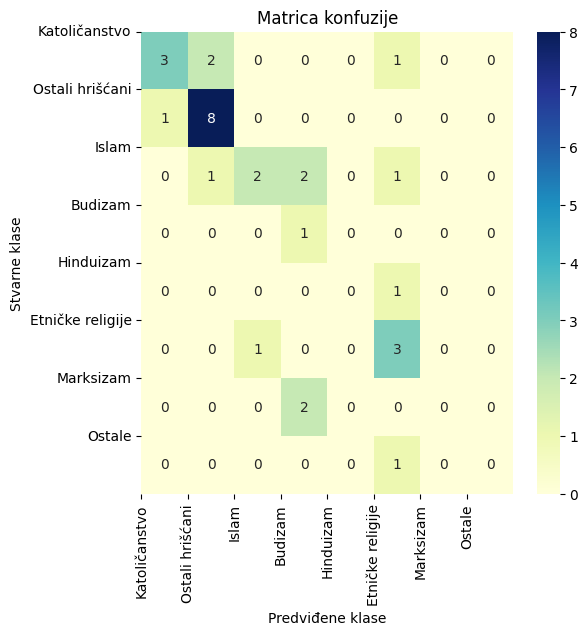

In [ ]:
conf_mat = confusion_matrix(y_test, y_pred)
religions = ["Katoličanstvo", "Ostali hrišćani", "Islam", "Budizam", "Hinduizam", "Etničke religije", "Marksizam", "Ostale"]
plt.figure(figsize=[6, 6])
sns.heatmap(conf_mat,
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            )
plt.title("Matrica konfuzije")
plt.xlabel("Predviđene klase")
plt.ylabel("Stvarne klase")
plt.xticks(ticks=[0,1,2,3,4,5,6,7], labels=religions, rotation=90)
plt.yticks(ticks=[0,1,2,3,4,5,6,7], labels=religions, rotation=0)
plt.show()

**SHAP analiza feature-a**

Pomoću SHAP vrednosti može se videti koji feature-i najviše utiču na konfuziju između klasa kod kojih postoji najviše grešaka. Proverava se uticaj feature na odabir katoličanstva i islama kod kojih je bilo najviše lažno negativnih pogodaka i etničkih religija i budizma kod kojih je bilo najviše lažno pozitivnih. Pre toga je proveren globalni uticaj feature-a na ukupnu predikciju svih religija.

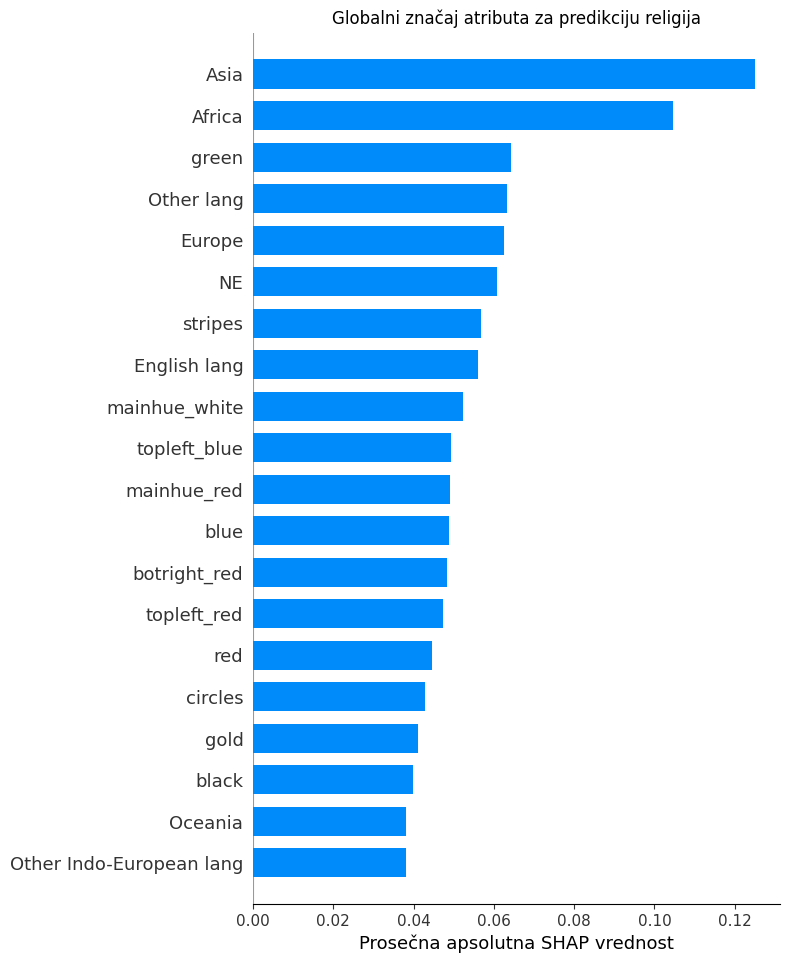

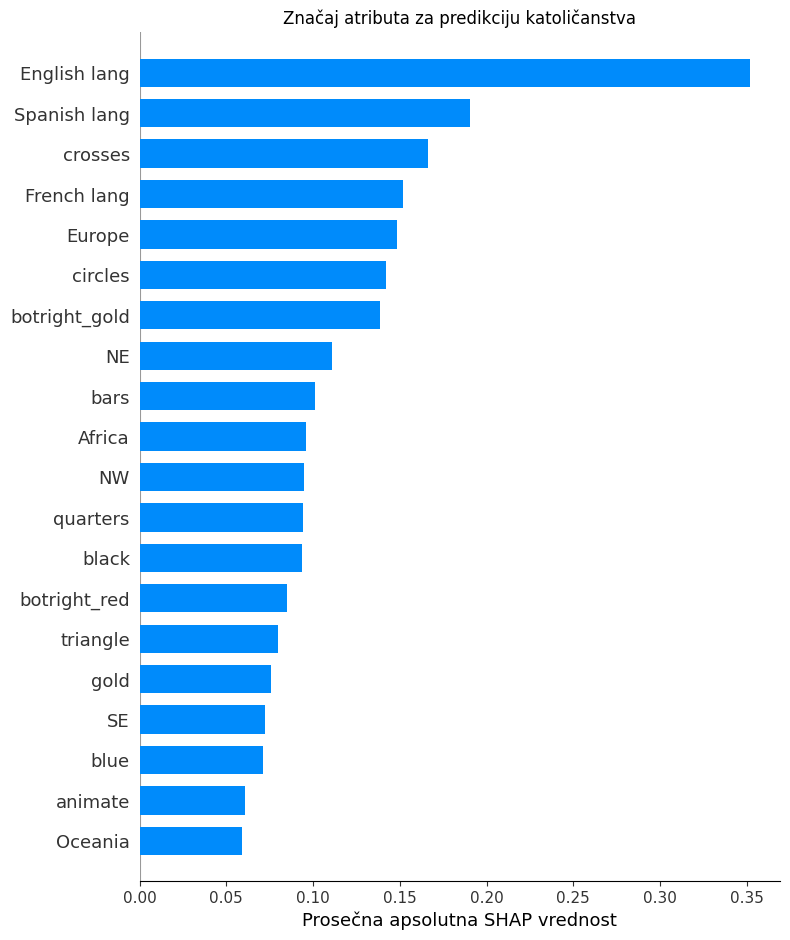

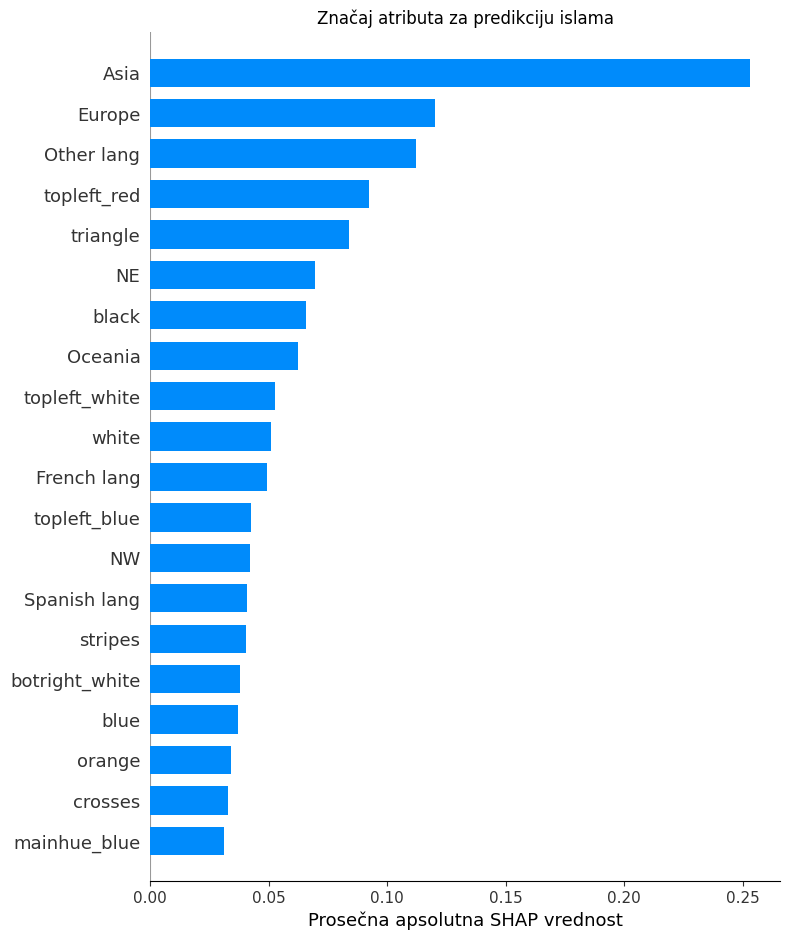

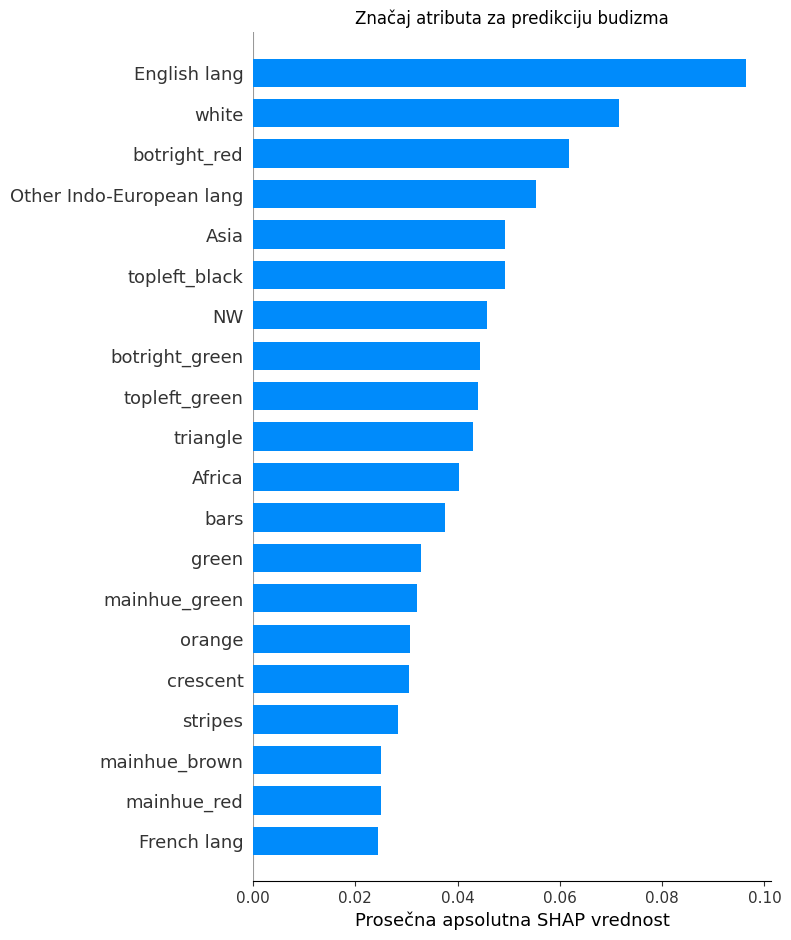

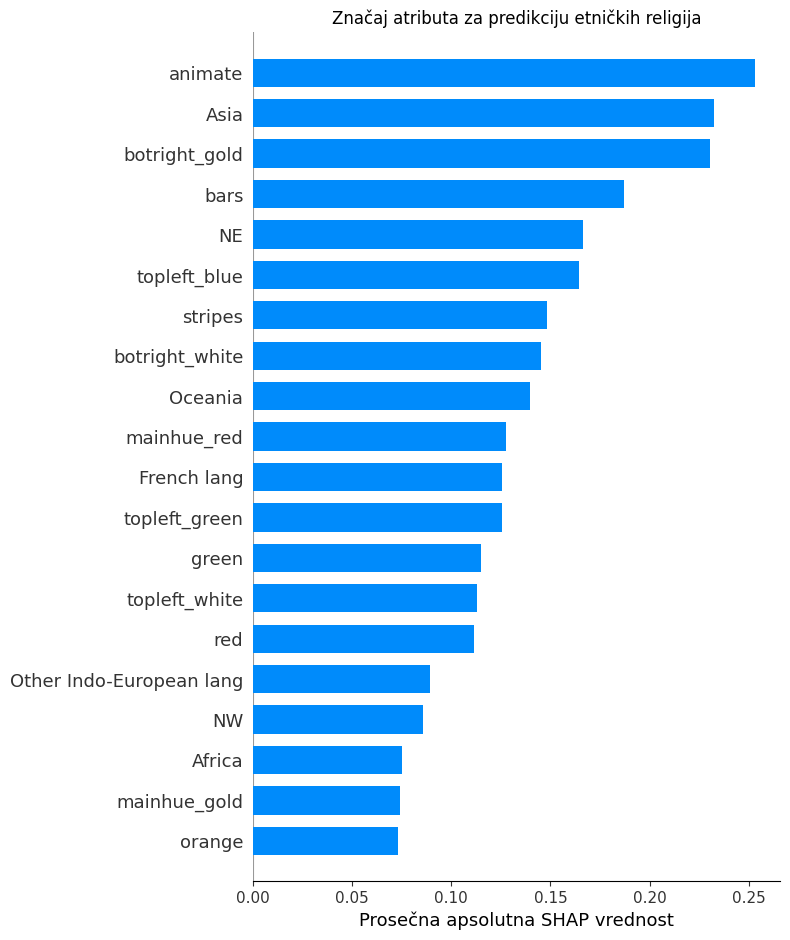

In [ ]:
explainer = shap.LinearExplainer(best_model[0], x_train)
shap_values = explainer.shap_values(x_test)

mean_shap_values = np.abs(shap_values).mean(axis=2)
shap.summary_plot(mean_shap_values, x_test, plot_type="bar", show=False)
plt.title("Globalni značaj atributa za predikciju religija")
plt.xlabel("Prosečna apsolutna SHAP vrednost")
plt.show()

shap_values_catholic = shap_values[:,:,0]
plt.figure(figsize=(4, 4))
plt.title("Značaj atributa za predikciju katoličanstva")
class_names = ['Ostali hrišćani', 'Islam', 'Budizam', 'Hinduizam', 'Etničke religije', 'Marksizam', 'Ostalo']

shap.summary_plot(shap_values_catholic, x_test, plot_type="bar", feature_names=x_test.columns, class_names=class_names, show=False)
plt.xlabel("Prosečna apsolutna SHAP vrednost")
plt.show()

shap_values_islam = shap_values[:,:,2]
plt.figure(figsize=(4, 4))
plt.title("Značaj atributa za predikciju islama")
class_names = ['Katoličanstvo', 'Ostali hrišćani', 'Budizam', 'Hinduizam', 'Etničke religije', 'Marksizam', 'Ostalo']

shap.summary_plot(shap_values_islam, x_test, plot_type="bar", feature_names=x_test.columns, class_names=class_names, show=False)
plt.xlabel("Prosečna apsolutna SHAP vrednost")
plt.show()

shap_values_budist = shap_values[:,:,3]
plt.figure(figsize=(4, 4))
plt.title("Značaj atributa za predikciju budizma")
class_names = ['Katoličanstvo', 'Ostali hrišćani', 'Islam', 'Hinduizam', 'Etničke religije', 'Marksizam', 'Ostalo']

shap.summary_plot(shap_values_budist, x_test, plot_type="bar", feature_names=x_test.columns, class_names=class_names, show=False)
plt.xlabel("Prosečna apsolutna SHAP vrednost")
plt.show()

shap_values_ethnic = shap_values[:,:,5]
plt.figure(figsize=(4, 4))
plt.title("Značaj atributa za predikciju etničkih religija")
class_names = ['Katoličanstvo', 'Ostali hrišćani', 'Islam', 'Budizam', 'Hinduizam', 'Marksizam', 'Ostalo']

shap.summary_plot(shap_values_ethnic, x_test, plot_type="bar", feature_names=x_test.columns, class_names=class_names, show=False)
plt.xlabel("Prosečna apsolutna SHAP vrednost")
plt.show()


Zaključci koje možemo izvesti na osnovu SHAP analize su da model donosi predikcije najviše na osnovu kontinenta na kojem se država nalazi, a takođe bitni atributi su i jezik, kao i boje (dominantne i boje na ivicama). Atributi kao što su veličina i broj stanovnika nisu nigde prepoznati kao značajni za predikciju religije, što može biti posledica normalizacije, ali i njihovog stvarnog malog značaja.  

*  Kod predikcije katoličanstva interesantno kontinenti nisu bili bitni atributi već njih zamenjuju jezici kao najvažniji feature i oblici na zastavi (krstevi, krugovi) što i odgovara rezultatima ekpslorativne analize.

 * Kod islama, najvažniji feature je bio azijski kontinent, a takođe i ostali jezici su bitan atribut dok na primer model nije uspeo da prepozna arapski jezik kao bitan atribut za predikciju islama.
 * Model je stavio akcenat na engleski jezik za predikciju budizma i otud i postojanje velikog broja lažno pozitivnih rezultata. Ostali bitni atributi kao što su bela i crvena boja na zastavi i Azijski kontinent su dobro prepoznati.
 * Kod etničkih religija u skladu sa rezultatima eksplorativne analize model je prepoznao zajedničko postojanje animate(grbova - slika) i zlatne boje na zastavi, i njima dodelio najveću važnost. Ipak ovi atributi nisu specifični samo za etničke religije pa je to izazvalo i dosta lažno pozitivnih pogodaka.

## **Neuronska mreža**

Neouronska mreža koja će se prikazati u narednom delu projekta bazirana je na primeru iz priložene literature. Stoga, ona će biti višeslojna perceptronska, tačnije imaće tri sloja.

**Biblioteke potrebne u delu koji se koristi za neuronsku mrežu**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, f1_score, log_loss
import shap

**Učitavanje skupa podataka**

In [ ]:
uploaded = files.upload()

columns = [
    "name","landmass","zone","area","population","language","religion","bars","stripes","colours",
    "red","green","blue","gold","white","black","orange","mainhue","circles","crosses",
    "saltires","quarters","sunstars","crescent","triangle","icon","animate","text","topleft","botright"
]

df = pd.read_csv("flag.data", header=None, names=columns)

Saving flag.data to flag (9).data


Isti princip kao i pre.

**Definisanje target kolone i pretprocesiranje podataka**

In [ ]:
target_col = "religion"

X = df.drop(columns=[target_col, "name"])
y = df[target_col]

X = pd.get_dummies(X, columns=["mainhue", "topleft", "botright", "landmass", "zone", "language"])

# Zbog jasnijeg ispisa u kasnijoj analizi feature-a menjamo imena kolona
def_landmass_names = ["landmass_1", "landmass_2", "landmass_3", "landmass_4", "landmass_5", "landmass_6"]
def_zone_names = ["zone_1", "zone_2", "zone_3", "zone_4"]
def_language_names = ["language_1", "language_2", "language_3", "language_4", "language_5", "language_6", "language_7", "language_8", "language_9", "language_10"]

landmasses = ["N. America", "S. America", "Europe", "Africa", "Asia", "Oceania"]
zones = ["NE", "SE", "SW", "NW"]
languages = ["English lang", "Spanish lang", "French lang", "German lang", "Slavic lang", "Other Indo-European lang", "Chinese lang", "Arabic lang", "Jap/Tur/Fin/Mag lang", "Other lang"]

X = X.rename(columns=dict(zip(def_landmass_names, landmasses)))
X = X.rename(columns=dict(zip(def_zone_names, zones)))
X = X.rename(columns=dict(zip(def_language_names, languages)))

# Standardizacija
scaler = StandardScaler()
columns_for_scale = ["area", "population", "bars", "stripes", "colours", "circles", "crosses", "saltires", "quarters", "sunstars"]
X = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

Radimo isto pretprocesiranje kao i za prethodna dva modela. Radimo one-hot encoding za kategorička obeležja i vršimo normalizaciju podataka sa kontinualnim vrednostima uz pomoć StandardScaler-a.

**Podela na trening i test skup podataka**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

Isti princip kao i ranije.

**Postavljanje parametara neuronske mreže**

In [ ]:
pipeline_mlp = Pipeline([
    ("mlp", MLPClassifier(
        activation='relu',
        solver='lbfgs', #adam bio pre, dosta se poboljšalo sa lbfgs-om
        random_state=42
    ))
])

Pre bilo čega u ovom procesu urađena je standardizacija podataka pomoću **StandardScaler** metode, kako bi svi atributi bili na istoj skali. Ovo je neophodno jer neuronske mreže koriste gradijentne metode optimizacije koje su osetljive na različite opsege vrednosti atributa.

Dalje, kao što je rečeno, postoje tri sloja. Prvi je ulazni, drugi je skriveni, a treći je izlazni sloj.

Skriveni sloj koristi **ReLu** aktivaciju koja radi kao filter, gde će negativne vrednosti ignorisati, a pozitivne propuštati.

Kada je izlazni sloj u pitanju, on ima **SoftMax** aktivaciju koja se impicitno koristi u okviru MLPClassfier, jer imamo više klasa na koje se obraća pažnja. Ova funkcija pretvara izlaz neurona u verovatnoću, pa će model birati klasu sa najvećom verovatnoćom. Što se tiče funkcije gubitka, takođe se indirektno u okviru MLPClassifier koristi **Cross-Entropy Loss** koja meri razliku između stvarne distribucije klasa i verovatnoća koje model predviđa. Model se trenira tako da minimizuje ovu vrednost, odnosno da dodeli što veću verovatnoću tačnoj klasi.

Korišćen je optimizacioni algoritam **lbfgs** koji optimizuje težine neurona u mreži koji je pogodan za male skupova podataka kakav je naš, jer uči težine cele mreže, bez epoha. ***Stoga, ovde postojanje loss_curve nije podržano (par ćelija ispod će biti prikazan pokušaj ručne interpretacije).*** Prvobitno je bio korišćen **Adam** koji je ipak pogodniji za mreže sa više slojeva i veće skupove podataka, te smo posmatranjem dobijenih rezultata zaključili da nam više odgovara lbfgs u ovoj situaciji.

**Neuronska mreža i Grid Search**

In [ ]:
param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(20,), (50,), (100,)],
    "mlp__alpha": [0.0001, 0.001, 0.01]
}

grid_mlp = GridSearchCV(
    pipeline_mlp,
    param_grid_mlp,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_mlp.fit(X_train, y_train)

print("Najbolji hiperparametri (MLP):", grid_mlp.best_params_)
print("Najbolji prosečni F1 (CV):", grid_mlp.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Najbolji hiperparametri (MLP): {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (20,)}
Najbolji prosečni F1 (CV): 0.4802652949291605


Na trening skupu izvršena je
pretraga najboljih hiperparametara pomoću unakrsne
validacije sa pet particija. U svakoj iteraciji unakrsne
validacije četiri particije su korišćene za treniranje, dok je
peta služila za validaciju, i taj postupak je ponavljan dok
svaka particija nije jednom iskorišćena za validaciju. Na
osnovu postignutih rezultata izabrani su optimalni
hiperparametri, nakon čega je model ponovo treniran na
celom trening skupu.

Korišćeni parametri:
* Broj neurona u skrivenom sloju: 20, 50 i 100.
* Regularizacioni parametar Alpha: 0.0001, 0.001 i 0.01. Ako je vrednost mala može se desiti natprilagođavanje, a ako je vrednost velika moguća je pojava ograničenja i jednostavnosti modela.

Vidimo da je najbolja kombinacija parametara da imamo 20 neurona i da je Alpha 0.0001, što donosi f1 score oko 0.48.

**Vizuelizacija rezultata hiperparametara**

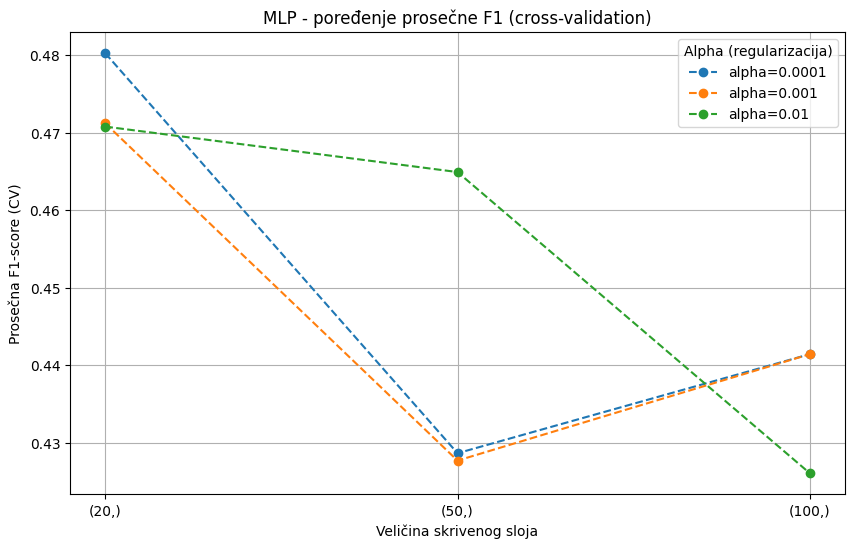

In [ ]:
results = pd.DataFrame(grid_mlp.cv_results_)

plt.figure(figsize=(10, 6))

for alpha in param_grid_mlp['mlp__alpha']:
    subset = results[results['param_mlp__alpha'] == alpha]
    plt.plot(
        [str(h) for h in subset['param_mlp__hidden_layer_sizes']],
        subset['mean_test_score'],
        marker='o',
        linestyle='dashed',
        label=f'alpha={alpha}'
    )

plt.title('MLP - poređenje prosečne F1 (cross-validation)')
plt.xlabel('Veličina skrivenog sloja')
plt.ylabel('Prosečna F1-score (CV)')
plt.legend(title="Alpha (regularizacija)")
plt.grid(True)
plt.show()

Ponovo, vidi se da je najbolji izbor kombinacija 20 neurona u skrivenom sloju sa vrednošću za parametar alpha 0,0001. Mali broj neurona kao najbolji izbor može biti posledica malog skupa podataka, sa jasnim relacijama između pojedinačnih atributa (kao što su na primer veze između kontinenta i strane sveta). Još manji broj neurona bi izvesno doveo do natprilagođavanja uzimajući u obzir izgled grafika i to da izlazni sloj ima 8 neurona. Vidimo da parametar regularizacije alpha daje najbolje rezultate za najmanju vrednost, ali s obzirom na to da i za veće vrednosti rezultati nisu mnogo lošiji možemo da pretpostavimo da nije došlo do natprilagođavanja.

**Evaluacija na test skupu**

In [ ]:
best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)

f1 = f1_score(y_test, y_pred_mlp, average="macro")

print("\nF1-score (TEST):", f1)


F1-score (TEST): 0.42658730158730157


Nakon izbora najboljih hiperparametara, model je automatski ponovo treniran na celokupnom trening skupu koristeći tu kombinaciju parametara.
Konačna vrednost f1 mere na podacima izdvojenim na početku
za testiranje je oko 0,42.

**Prikaz loss-a kroz log loss na trening skupu**

Može se simulirati loss funkcija tako što će se za svaku konfiguraciju mreže izračunavati log_loss na trening skupu.

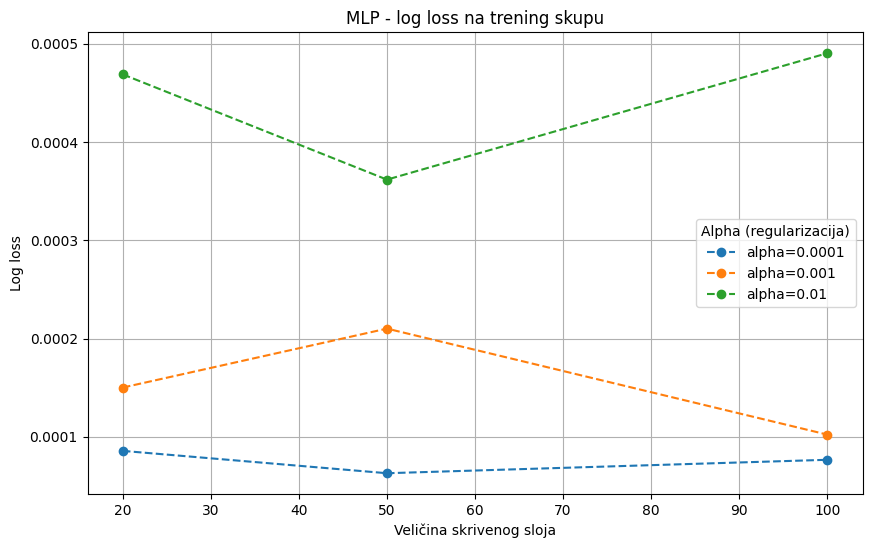

In [ ]:
hidden_layers = [(20,), (50,), (100,)]
alphas = [0.0001, 0.001, 0.01]

loss_records = []

for alpha in alphas:
    for hl in hidden_layers:
        mlp = MLPClassifier(
            hidden_layer_sizes=hl,
            alpha=alpha,
            solver='lbfgs',
            random_state=42
        )
        mlp.fit(X_train, y_train)
        probs = mlp.predict_proba(X_train)
        loss = log_loss(y_train, probs)
        loss_records.append({
            "hidden_layer_size": hl[0],
            "alpha": alpha,
            "log_loss": loss
        })

df_loss = pd.DataFrame(loss_records)

plt.figure(figsize=(10,6))
for alpha in alphas:
    subset = df_loss[df_loss['alpha'] == alpha]
    plt.plot(subset['hidden_layer_size'], subset['log_loss'], marker='o', linestyle='dashed', label=f'alpha={alpha}')

plt.title('MLP - log loss na trening skupu')
plt.xlabel('Veličina skrivenog sloja')
plt.ylabel('Log loss')
plt.legend(title='Alpha (regularizacija)')
plt.grid(True)
plt.show()

Pogled na grafik:
* Najniži loss je postignut za najmanju regularizaciju (alpha=0.0001).
* Povećanjem regularizacije (alpha=0.01) loss raste, što je očekivano jer regularizacija smanjuje kapacitet modela da precizno prati trening podatke.
* Za svaku vrednost alpha postoji mala varijacija u log lossu sa promenom broja neurona.
* Ovo sugeriše da model nije jako osetljiv na broj neurona u ovom opsegu, ali mala mreža (20 neurona) ponekad daje bolji rezultat nego veća (100 neurona), što može biti zbog optimizacije ili regularizacije.
* Model je relativno stabilan, i log loss je nizak, što znači da mreža uči distribuiranu verovatnoću klasa prilično dobro.

-> Još jednom, za MLP koristili smo solver lbfgs, koji je second-order optimizator i ne koristi iteracije po epohama kao adam ili sgd. Zbog toga scikit-learn ne čuva gubitak po iteracijama i ne postoji direktna loss_curve. Umesto toga, log loss smo izračunali ručno na trening skupu za različite hiperparametre kako bismo vizualizovali uticaj veličine skrivenog sloja i regularizacije.

**Izveštaj:**

In [ ]:
religion_labels = [
    "Katoličanstvo",
    "Ostali hrišćani",
    "Islam",
    "Budizam",
    "Hinduizam",
    "Etničke vere",
    "Marksizam",
    "Ostalo"
]

print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp, target_names=religion_labels, zero_division=0))


Classification report:
                 precision    recall  f1-score   support

  Katoličanstvo       0.75      0.50      0.60         6
Ostali hrišćani       0.75      1.00      0.86         9
          Islam       0.67      0.33      0.44         6
        Budizam       0.50      1.00      0.67         1
      Hinduizam       0.00      0.00      0.00         1
   Etničke vere       0.40      0.50      0.44         4
      Marksizam       0.33      0.50      0.40         2
         Ostalo       0.00      0.00      0.00         1

       accuracy                           0.60        30
      macro avg       0.42      0.48      0.43        30
   weighted avg       0.60      0.60      0.57        30



Rezultati pokazuju da model ostvaruje relativno nisku vrednost F1 mere (~0.43), što ukazuje na ograničenu sposobnost generalizacije.

Model postiže bolje rezultate za dominantnije klase kao što su "Ostali hrišćani" i "Katoličanstvo", dok za manje zastupljene klase (npr. Marksizam, Ostalo) često ne uspeva da napravi tačne predikcije ili to ne uspeva uopšte.

Ovo je posledica malog broja instanci u pojedinim klasama i nebalansiranog skupa podataka. Zbog toga model ima problem da nauči obrasce za retke klase.

**Matrica konfuzije**

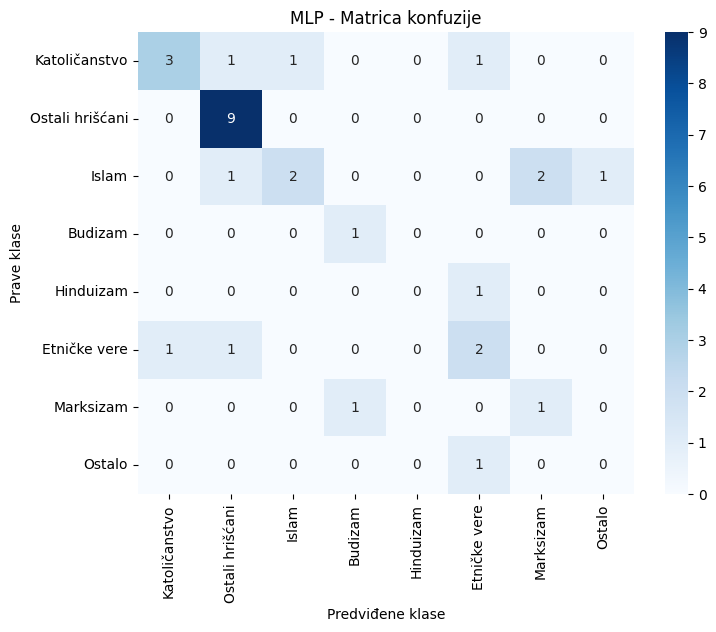

In [ ]:
conf_mat = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=religion_labels,
            yticklabels=religion_labels)

plt.title("MLP - Matrica konfuzije")
plt.xlabel("Predviđene klase")
plt.ylabel("Prave klase")
plt.show()

Model najbolje pogađa one klase za koje ima najviše primera poput katolika i ostalih hrišćana, dok tamo gde ima malo primera ne uspeva da nauči i pravi greške u predviđanju hinduizma i ostalih religija (nekad nije ni marksizam uopšte pogađan u prethodnim pokušajima). Sa druge strane i tamo gde ima više primera model može da se muči sa prepozavanjem što je vidljivo na primeru islama.

**Mala analiza grešaka**

In [ ]:
errors = X_test.copy()
errors["true"] = y_test
errors["pred"] = y_pred_mlp

errors = errors[errors["true"] != errors["pred"]]

print("Broj pogrešnih predikcija:", len(errors))
errors.head(10)

Broj pogrešnih predikcija: 12


,area,population,bars,stripes,colours,red,green,blue,gold,white,...,French lang,German lang,Slavic lang,Other Indo-European lang,Chinese lang,Arabic lang,Jap/Tur/Fin/Mag lang,Other lang,true,pred
82,0.556015,1.458414,-0.437990,0.193133,-1.128870,0.517662,-0.939944,-1.020836,-0.939944,0.573382,...,-0.309912,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,1.793709,2,1
111,-0.322375,-0.242844,-0.437990,1.054460,0.413389,0.517662,1.063893,0.979590,1.063893,-1.744037,...,-0.309912,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,-0.557504,4,5
85,-0.290971,-0.221033,2.458716,-0.668195,-0.357740,-1.931763,1.063893,-1.020836,-0.939944,0.573382,...,-0.309912,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,-0.557504,0,1
29,-0.310367,-0.210128,-0.437990,-0.668195,-0.357740,0.517662,1.063893,-1.020836,-0.939944,0.573382,...,-0.309912,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,1.793709,5,1
171,-0.296974,-0.231939,-0.437990,1.485124,0.413389,0.517662,1.063893,-1.020836,1.063893,0.573382,...,3.226727,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,-0.557504,7,5
188,-0.169511,0.400580,-0.437990,-0.668195,-1.128870,0.517662,-0.939944,-1.020836,1.063893,-1.744037,...,-0.309912,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,1.793709,6,3
105,-0.169511,-0.111978,-0.437990,5.361097,0.413389,0.517662,-0.939944,0.979590,1.063893,0.573382,...,-0.309912,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,1.793709,2,7
35,0.269684,-0.210128,2.458716,-0.668195,-0.357740,0.517662,-0.939944,0.979590,1.063893,-1.744037,...,3.226727,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,-0.557504,5,0
25,-0.320528,-0.253750,-0.437990,-0.668195,0.413389,0.517662,-0.939944,-1.020836,1.063893,0.573382,...,-0.309912,-0.178647,-0.145095,-0.427699,-0.145095,-0.329502,-0.145095,1.793709,2,6
32,-0.321451,-0.253750,0.527579,0.193133,1.184519,0.517662,1.063893,-1.020836,1.063893,-1.744037,...,-0.309912,-0.178647,-0.145095,2.338090,-0.145095,-0.329502,-0.145095,-0.557504,0,5


Nekad bilo 17 grešaka, sada se svelo na 12 usled standardizacije.

Analiza grešaka modela izvršena je izdvajanje primera na kojima model daje pogrešne predikcije. Svaki red u toj analizi predstavlja konkretan primer iz skupa podataka (identifikovan originalnim indeksom), zajedno sa stvarnom klasom i predikcijom modela.

In [ ]:
error_pairs = errors.groupby(["true", "pred"]).size().reset_index(name="count")

error_pairs = error_pairs.sort_values(by="count", ascending=False)
error_pairs = error_pairs.reset_index(drop=True)

print(error_pairs)

    true  pred  count
0      2     6      2
1      0     2      1
2      0     1      1
3      0     5      1
4      2     1      1
5      2     7      1
6      4     5      1
7      5     0      1
8      5     1      1
9      6     3      1
10     7     5      1


Dodatno, izvršena je agregacija grešaka grupisanjem po stvarnoj i predviđenoj klasi. Na ovaj način identifikovani su najčešći tipovi grešaka. Na primer, uočeno je da model često klasifikuje određene religije kao druge, što može da ukazuje na sličnost u atributima između tih klasa (npr. dva puta mešanje islama što je oznaka 2 sa marksizmom što je oznaka 6).

**SHAP analiza**

In [ ]:
def predict_fn(X):
    X = pd.DataFrame(X, columns=X_train.columns)
    return best_mlp.predict_proba(X) #vraća niz v-ća za sve klase

explainer = shap.KernelExplainer(predict_fn, X_train)
shap_values = explainer.shap_values(X_test)

SHAP očekuje funkciju koja prima samo ulazne podatke i vraća izlaz modela (kod klasifikacije – verovatnoće za svaku klasu). X koji SHAP prosleđuje može biti NumPy niz, a model ovde radi sa DataFrame-om sa imenima kolona, zato se obezbeđuje da model zna koje kolone koristi.

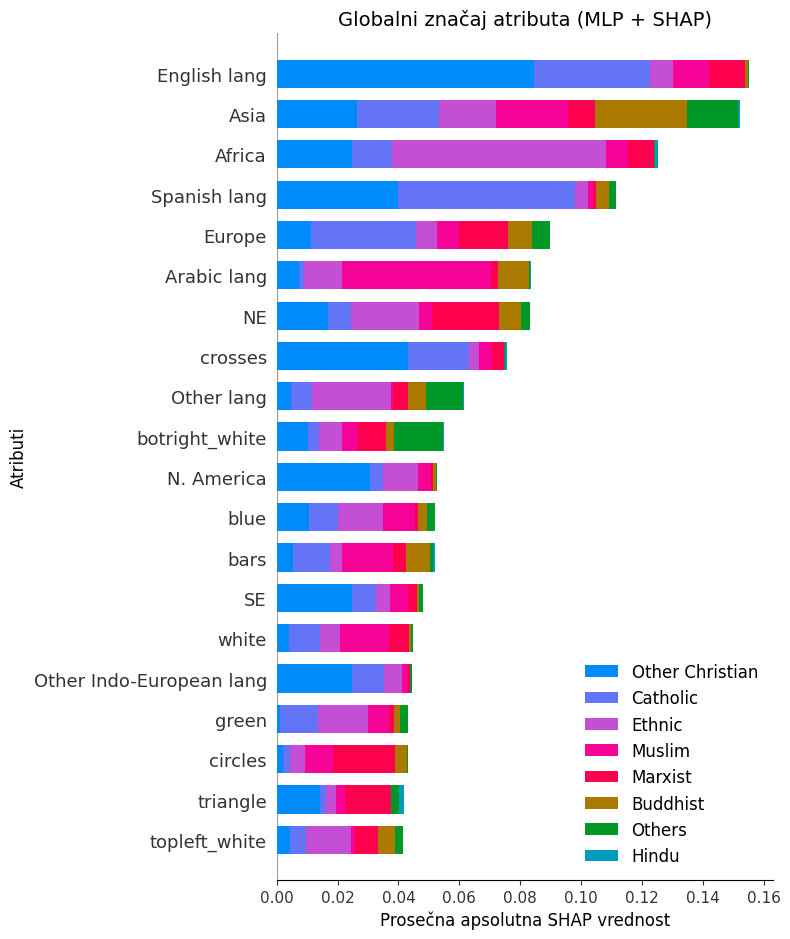

In [ ]:
religion_labels = {0: 'Catholic', 1: 'Other Christian', 2: 'Muslim',3: 'Buddhist', 4: 'Hindu', 5: 'Ethnic', 6: 'Marxist', 7: 'Others'}
class_names = list(religion_labels.values())

plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=X_test.columns,
    class_names=class_names,
    show=False
)

plt.title("Globalni značaj atributa (MLP + SHAP)", fontsize=14)
plt.xlabel("Prosečna apsolutna SHAP vrednost", fontsize=12)
plt.ylabel("Atributi", fontsize=12)
plt.tight_layout()
plt.show()


Primetno je da je među najkorisnijim atributima za određivanje religije ovom modelu najvažnije bilo koristi podatke o jeziku, kontinentu, geografskom kvadrantu i postojanju krstova na zastavi.

Sada sledi prikaz po svakoj religiji zasebno šta je najviše doprinelo određivanju baš te relgije od postojećih atributa:

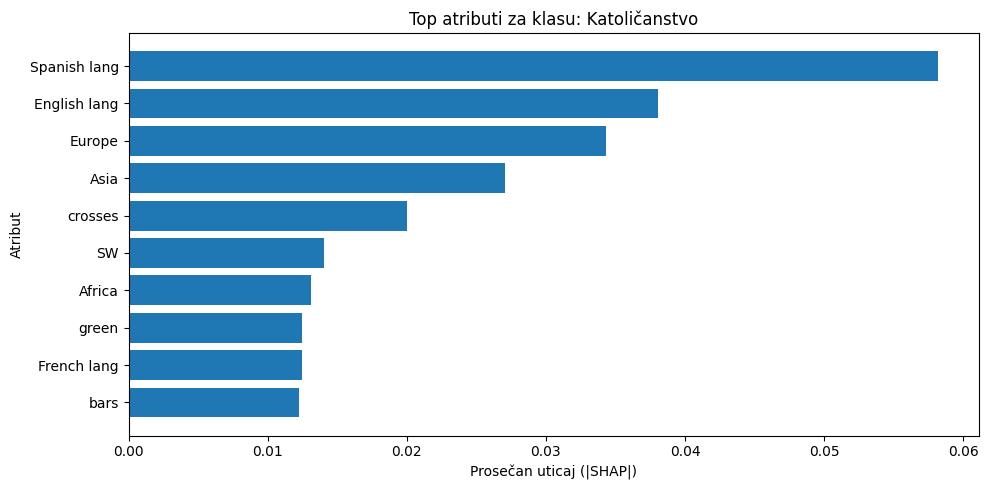

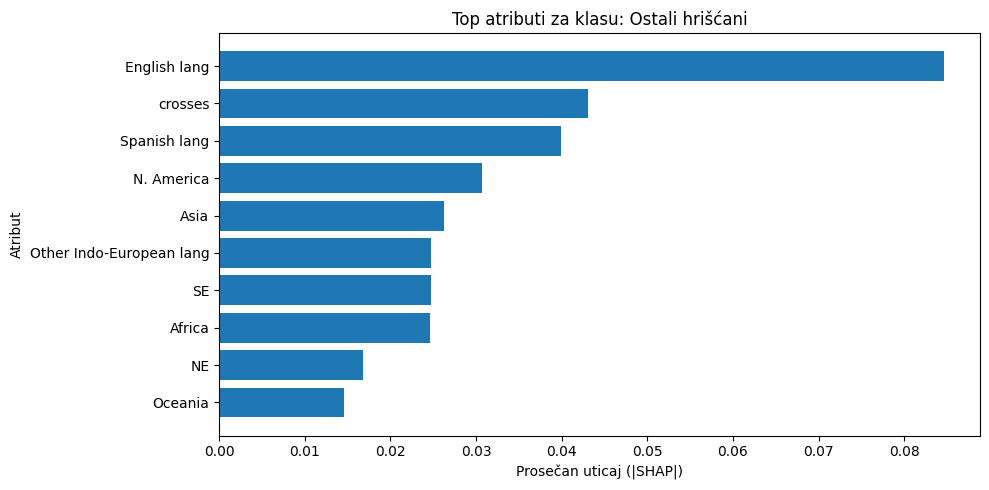

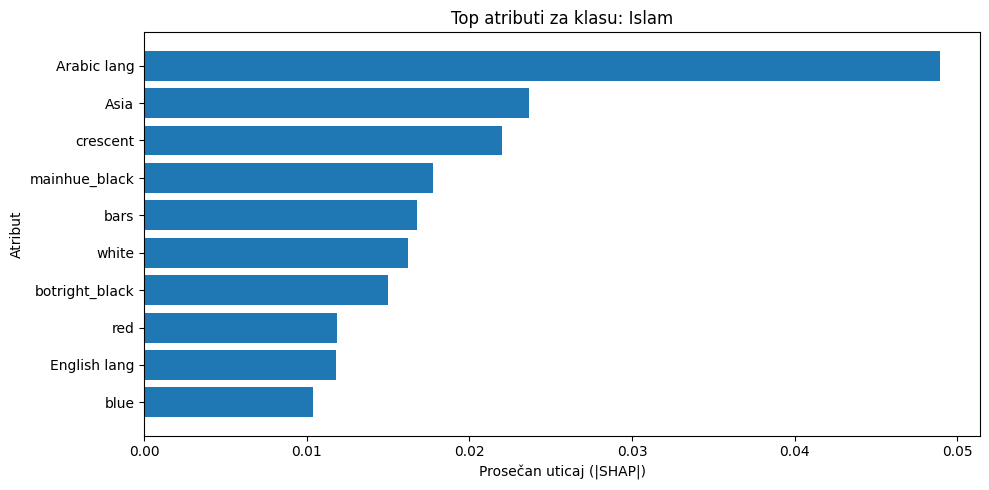

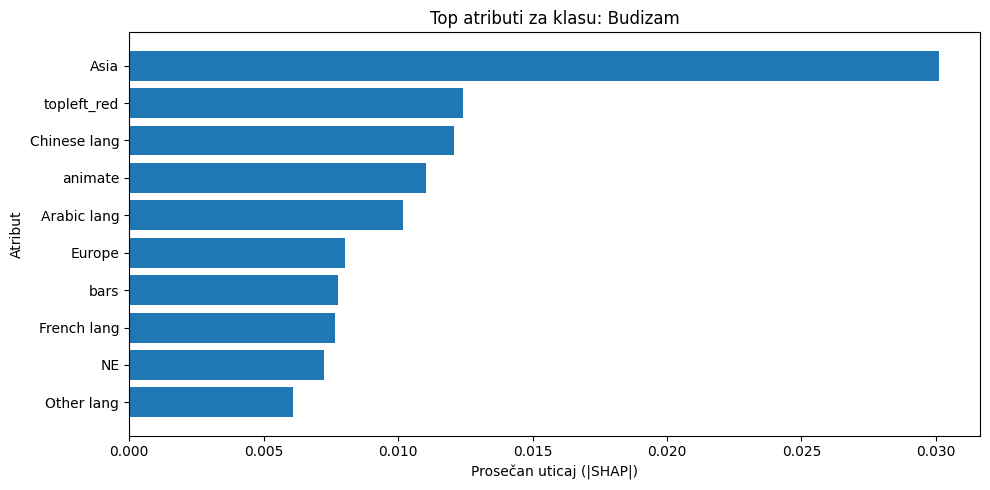

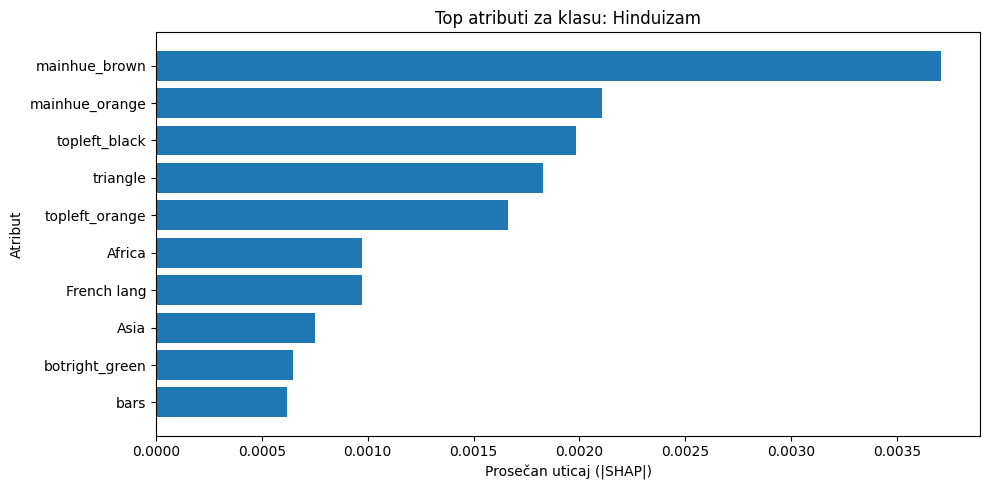

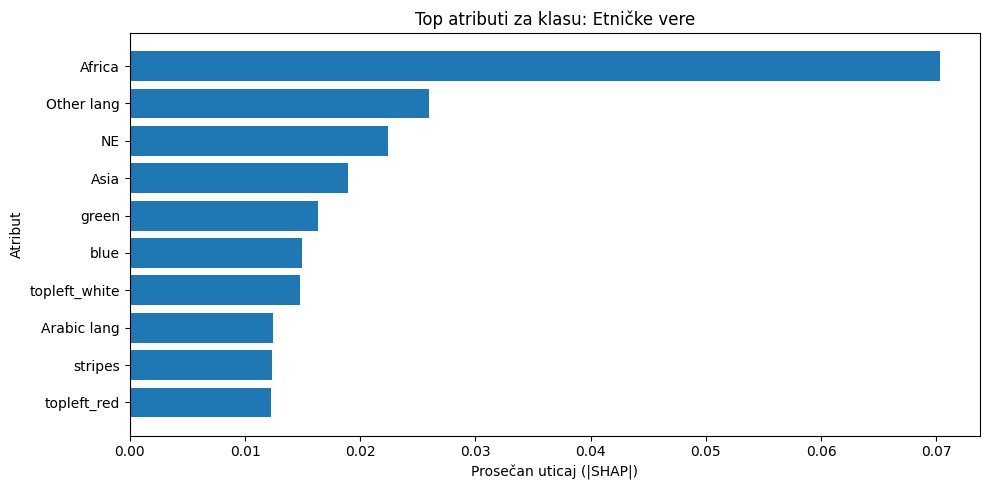

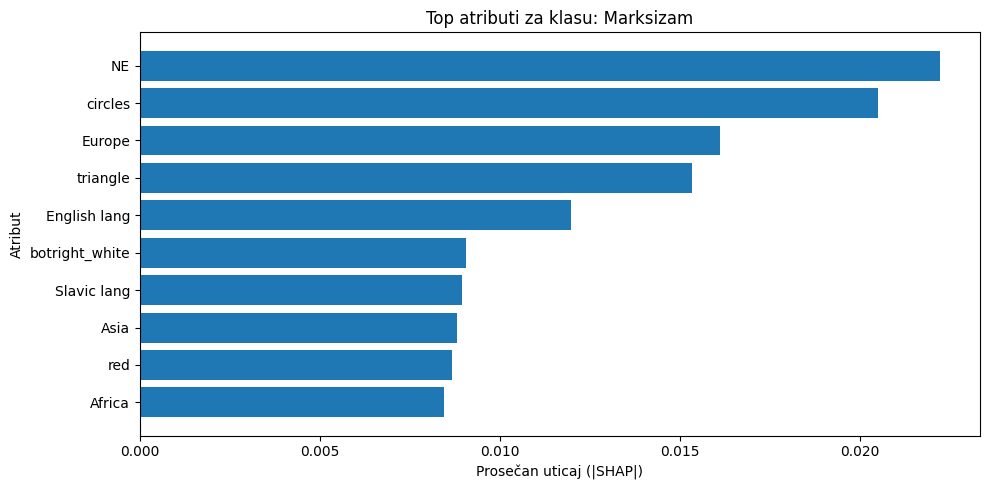

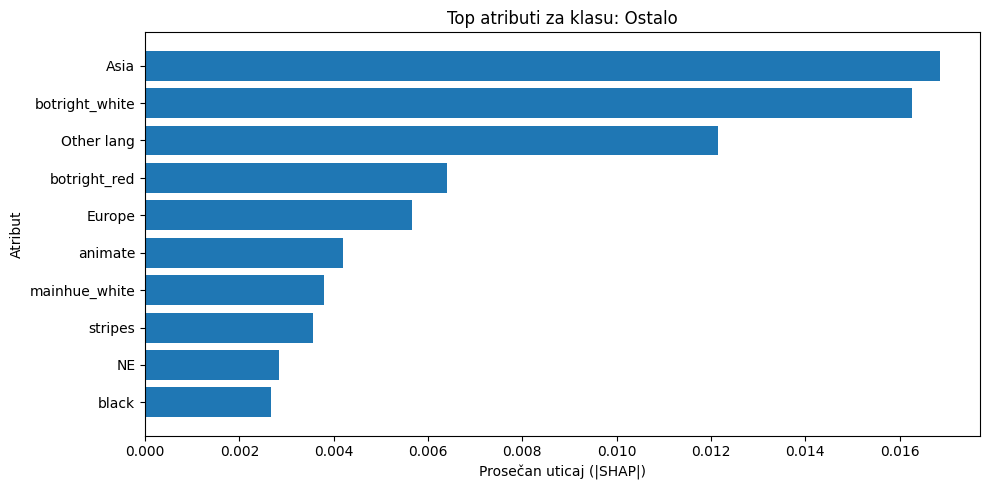

In [ ]:
religion_labels = [
    "Katoličanstvo",
    "Ostali hrišćani",
    "Islam",
    "Budizam",
    "Hinduizam",
    "Etničke vere",
    "Marksizam",
    "Ostalo"
]

# shap_values shape: (samples, features, classes)

for i, class_name in enumerate(religion_labels):
    shap_class = shap_values[:, :, i]

    mean_importance = np.abs(shap_class).mean(axis=0)

    df_imp = pd.DataFrame({
        "feature": X_test.columns,
        "importance": mean_importance
    }).sort_values(by="importance", ascending=False).head(10)

    plt.figure(figsize=(10,5))
    plt.barh(df_imp["feature"], df_imp["importance"])
    plt.gca().invert_yaxis()

    plt.title(f"Top atributi za klasu: {class_name}")
    plt.xlabel("Prosečan uticaj (|SHAP|)")
    plt.ylabel("Atribut")
    plt.tight_layout()
    plt.show()

Vidimo da postoje različiti uticaji po religijama, što i ima smisla, neće se svaka religija određivati zahvaljujući istoj kombinaciji parametara.
* Kod katoličanstva dosta velik uticaj ispravno nose španski i engleski jezik, kao i krstovi na zastavama.
* Ostali hrišćani su najbolje pogađani, a iako su najvažniji atributi slični kao i kod katoličanstva, model je uglavnom uspešno uspeo da ih razazna na osnovu ostalih atributa.
* Neuronska mreža za razliku od SVM-a je uspela da prepozna važnost arapskog jezika za prepoznavanje islama, kao i azijskog kontinenta i polumeseca. Ipak uprkos tome ima slabe rezultate predikcije ove religije.
* Ubedljivo najvažniji feature-i za prepoznavanje budizma su azijski kontinent i kineski jezik što je model ispravno prepoznao.
* Za predikciju hinduizma mreža je prepoznala kao najvažnije dominantne boje na zastavi. Ipak kako je to religija sa najmanjim brojem zemalja u skupu podataka njeno prepoznavanje nije dalo naročito dobre rezultate.
* Najvažniji atributi za prepoznavanje etničkih vera su afrički kontinent i ostali jezici. Azijski kontinent, prisustvo zelene boje na zastavi i severo istočna strana sveta su najverovatnije prouzrokovale lažno pozitivne rezultate iz klasa islam i hinduizam.
* Kod marksizma, za razliku od prethodnih religija najvažniji atribut nema tako izražen uticaj, već severo-istočni kvadrant, broj krugova i trouglova i Evropa dele uticaj.
* Ostale religije za najvažnije atribute imaju Azijski kontinent, belu boju na donjem delu zastave i ostale jezike.